## Extraer características

El objetivo de este notebook es extraer las características necesarias entre el cuerpo de la noticia que puedan dar indicios de clickbait y ver si se diferencia en el espacio reducido con el UMAP

### Librerías

In [1]:
import spacy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer
from umap import UMAP


from sentence_transformers import CrossEncoder
from scipy.special import expit


import re
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import StandardScaler

nltk.download("punkt")
nltk.download('stopwords')
nlp = spacy.load("es_core_news_sm")
stop = stopwords.words('spanish')


embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2") # paraphrase-multilingual-mpnet-base-v2 paraphrase-multilingual-MiniLM-L12-v2


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1778829145.509287    1396 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778829147.525681    1396 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punk

### Funciones principales

In [2]:
def dividir_contenido(texto, palabras_por_fragmento=15):
    palabras = texto.split()
    fragmentos = []
    for i in range(0, len(palabras), palabras_por_fragmento):
        fragmento = " ".join(palabras[i:i + palabras_por_fragmento])
        fragmentos.append(fragmento)
    return fragmentos

def cargar_datos(noticias, n_noticia=0, print_info=False):
    """
    Carga título y contenido de una noticia
    input: n_noticia (int): índice de noticia
    output: titulo, fragmentos_contenido (list)
    """
    noticia = noticias[n_noticia]
    titulo = noticia["Título"]
    contenido = noticia["Contenido"]
    #fragmentos_contenido = sent_tokenize(contenido, language='spanish')
    fragmentos_contenido = dividir_contenido(contenido, palabras_por_fragmento=10)
    if print_info:
        print(f"Título: {titulo}\n")
        print(f"\nFragmentos:")
        for i, frag in enumerate(fragmentos_contenido, 1):
            print(f"  Fragmento {i}: {frag}")
    
    return titulo, fragmentos_contenido,noticia


def extraer_features_linguisticos(corpus):
    """
    Extrae features lingüísticas relacionadas con clickbait.

    Parameters
    ----------
    corpus : list[str]
        Lista de textos.

    Returns
    -------
    np.ndarray
        Array shape (n_textos, n_features)
    """

    # =====================================================
    # Diccionarios léxicos
    # =====================================================

    deicticos = {
        'yo', 'tú', 'tu', 'usted', 'ustedes',
        'él', 'ella', 'ellos', 'ellas',
        'nosotros', 'nosotras',
        'vosotros', 'vosotras',
        'me', 'te', 'se', 'nos', 'os',
        'le', 'les',
        'mi', 'mis',
        'tus', 'su', 'sus',
        'nuestro', 'nuestra',
        'vuestro', 'vuestra',
        'este', 'esta', 'estos', 'estas',
        'ese', 'esa', 'esos', 'esas',
        'aquel', 'aquella',
        'aquí', 'ahí', 'allí',
        'ahora', 'hoy', 'mañana',
        'esto', 'eso', 'aquello'
    }

    intensificadores = {
        'muy', 'sumamente', 'extremadamente',
        'increíblemente', 'absolutamente',
        'totalmente', 'completamente',
        'realmente', 'verdaderamente',
        'demasiado', 'especialmente',
        'particularmente', 'sorprendentemente',
        'brutalmente', 'impresionantemente',
        'enormemente', 'terriblemente'
    }

    superlativos = {
        'mejor', 'peor', 'máximo', 'mínimo',
        'mayor', 'menor', 'último', 'primero',
        'buenísimo', 'malísimo',
        'importantísimo', 'gravísimo',
        'rarísimo', 'famosísimo',
        'enormísimo'
    }

    emocionales = {
        'increíble', 'impactante',
        'sorprendente', 'brutal',
        'impresionante', 'escandaloso',
        'alarmante', 'insólito',
        'inesperado', 'viral',
        'polémico', 'emocionante',
        'dramático', 'sorprendido',
        'devastador', 'terrible',
        'histórico', 'explosivo'
    }

    curiosity_gap = {
        'no creerás',
        'nadie esperaba',
        'lo que pasó',
        'te sorprenderá',
        'se vuelve viral',
        'está arrasando',
        'deja sin palabras',
        'causa furor',
        'no podrás creer',
        'todo el mundo habla',
        'revoluciona las redes',
        'se hace viral'
    }

    # =====================================================
    # Extracción de features
    # =====================================================

    features = []

    for texto in corpus:

        texto_lower = texto.lower()

        palabras = word_tokenize(
            texto_lower,
            language="spanish"
        )

        n_palabras = max(len(palabras), 1)

        # -----------------------------
        # Conteos léxicos
        # -----------------------------

        deicticos_count = sum(
            1 for p in palabras
            if p in deicticos
        )

        intensificadores_count = sum(
            1 for p in palabras
            if p in intensificadores
        )

        emocionales_count = sum(
            1 for p in palabras
            if p in emocionales
        )

        superlativos_count = sum(
            1 for p in palabras
            if (
                p in superlativos
                or any(
                    suf in p
                    for suf in [
                        'ísimo',
                        'ísima',
                        'ísimos',
                        'ísimas'
                    ]
                )
            )
        )

        # -----------------------------
        # Curiosity gap
        # -----------------------------

        curiosity_count = sum(
            1 for expr in curiosity_gap
            if expr in texto_lower
        )

        # -----------------------------
        # Puntuación
        # -----------------------------

        exclamaciones = len(
            re.findall(r'[!¡]', texto)
        )

        interrogaciones = len(
            re.findall(r'[?¿]', texto)
        )

        puntos_suspensivos = texto.count("...")

        mayusculas = len(
            re.findall(r'\b[A-ZÁÉÍÓÚÑ]{2,}\b', texto)
        )

        numeros = len(
            re.findall(r'\b\d+\b', texto)
        )

        # -----------------------------
        # Ratios normalizados
        # -----------------------------

        deicticos_ratio = deicticos_count / n_palabras
        intensificadores_ratio = intensificadores_count / n_palabras
        emocionales_ratio = emocionales_count / n_palabras
        superlativos_ratio = superlativos_count / n_palabras

        # -----------------------------
        # Vector final
        # -----------------------------

        features.append([
            deicticos_count,
            intensificadores_count,
            superlativos_count,
            emocionales_count,
            curiosity_count,
            exclamaciones,
            interrogaciones,
            # puntos_suspensivos,
            # mayusculas,
            # numeros,
            deicticos_ratio,
            intensificadores_ratio,
            emocionales_ratio,
            superlativos_ratio
        ])

    return np.array(features)


def calcular_diferencia_features(corpus):
    """
    Calcula diferencia de features entre título y fragmentos
    input: corpus (list): lista de textos
    output: diferencias (array), features normalizados (tuple)
    """
    
    features = extraer_features_linguisticos(corpus)
    
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features)
    
    titulo_norm = features_norm[0]
    fragmentos_norm = features_norm[1:]
    
    diferencias = np.linalg.norm(fragmentos_norm - titulo_norm, axis=1)
    
    return diferencias, (titulo_norm, fragmentos_norm)


# =========================
# LSA (reducción a 2D)
# =========================

def LSA_vectors(corpus,min_df=1,plot=False):
    tfidf_vectorizer = TfidfVectorizer(min_df=min_df)
    tfidf = tfidf_vectorizer.fit_transform(corpus)


    n_components = min(2, tfidf.shape[0] - 1)
    lsa = TruncatedSVD(n_components=n_components, random_state=42)
    tfidf_lsa = lsa.fit_transform(tfidf)
    titulo_vector = tfidf[0]
    fragmentos_vectors = tfidf[1:]
    similitudes = cosine_similarity(titulo_vector, fragmentos_vectors)[0]
    # if plot:
    #     plt.figure(figsize=(10, 6))
    #     colors = ['red'] + ['blue'] * len(fragmentos_contenido)
    #     labels = ['Título'] + [f'Frag {i+1}' for i in range(len(fragmentos_contenido))]

    #     plt.scatter(tfidf_lsa[:, 0], tfidf_lsa[:, 1], c=colors, s=100, alpha=0.6)
    #     for i, label in enumerate(labels):
    #         plt.annotate(label, (tfidf_lsa[i, 0], tfidf_lsa[i, 1]), fontsize=9, ha='center')

    #     plt.xlabel('LSA Component 1')
    #     plt.ylabel('LSA Component 2')
    #     plt.title('Distribución LSA: Título vs Fragmentos')
    #     plt.grid(True, alpha=0.3)
    #     plt.tight_layout()
    #     plt.show()

    return similitudes,tfidf_lsa



# ----------------------------
# ESPACIO EMBEDDING CON SENTENCE TRANSFORMERS
# ----------------------------


def embedding_sentence_transformers(corpus,embedding_model):
    embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
    )
    titulo_embedding = embeddings[0]
    fragmentos_embeddings = embeddings[1:]

    similarities = cosine_similarity(
        [titulo_embedding],
        fragmentos_embeddings
    )[0]

    return similarities,embeddings

def embedding_umap(similarities,embeddings, plot=False):
    reducer = UMAP(
    n_neighbors = min(5, len(embeddings) - 1), # Pongo esto porque a veces hay tan pocos que da error
    n_components=2,
    init="random",
    min_dist=0.1,
    metric="cosine",
    random_state=42
    )
    embedding_2d = reducer.fit_transform(embeddings)
    if plot:
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]

        plt.figure(figsize=(10, 8))

        # Fragmentos
        scatter = plt.scatter(
            x[1:],
            y[1:],
            c=similarities,
            cmap="viridis",
            s=80,
            alpha=0.8
        )

        # Título
        plt.scatter(
            x[0],
            y[0],
            color="red",
            s=250,
            marker="X",
            label="Título"
        )

        # Etiquetas opcionales
        for i, (xi, yi) in enumerate(zip(x[1:], y[1:])):
            plt.text(
                xi,
                yi,
                str(i + 1),
                fontsize=8
            )

        plt.colorbar(
            scatter,
            label="Similitud coseno con título"
        )

        plt.title("Espacio semántico de la noticia")
        plt.xlabel("UMAP-1")
        plt.ylabel("UMAP-2")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()
    return embedding_2d


def embedding_cross_encoder(corpus):
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    pairs = [[corpus[0], fragmento] for fragmento in corpus[1:]]
    scores = cross_encoder.predict(pairs)
    probabilities = expit(scores)
    return probabilities



def calcular_shock_value(corpus):
    """
    Métrica diferencial: SHOCK VALUE
    Mide la intensidad emocional concentrada en el título vs el cuerpo.
    
    Lógica: Los titulares clickbait tienen picos emocionales fuertes al inicio,
    mientras que noticias normales distribuyen la emoción uniformemente.
    
    Parameters
    ----------
    corpus : list[str]
        [titulo, fragmento1, fragmento2, ...]
    
    Returns
    -------
    float
        Shock value entre 0 y 1
    """
    
    palabras_emocionales = {
        'increíble', 'impactante', 'sorprendente', 'brutal',
        'impresionante', 'escandaloso', 'alarmante', 'insólito',
        'inesperado', 'viral', 'polémico', 'emocionante',
        'dramático', 'devastador', 'terrible', 'histórico',
        'explosivo', 'chocante', 'perturbador', 'inquietante'
    }
    
    intensificadores = {
        'muy', 'sumamente', 'extremadamente', 'increíblemente',
        'absolutamente', 'totalmente', 'completamente', 'demasiado'
    }
    
    if len(corpus) < 2:
        return 0.0
    
    titulo = corpus[0].lower()
    fragmentos = [f.lower() for f in corpus[1:]]
    
    # Contar palabras emocionales e intensificadores
    def contar_emocionales(texto):
        palabras = texto.split()
        emocionales = sum(1 for p in palabras if p in palabras_emocionales)
        intensif = sum(1 for p in palabras if p in intensificadores)
        return emocionales + (intensif * 0.5)  # Pesar menos intensificadores
    
    # Densidad emocional del título
    titulo_emocional = contar_emocionales(titulo) / max(len(titulo.split()), 1)
    
    # Densidad emocional promedio del cuerpo
    if fragmentos:
        cuerpo_emocional = np.mean([
            contar_emocionales(f) / max(len(f.split()), 1) 
            for f in fragmentos
        ])
    else:
        cuerpo_emocional = 0
    
    # Shock value: proporción de emoción en el título
    # Clickbait: título muy emocional, cuerpo aburrido
    # Normal: emoción distribuida
    if titulo_emocional + cuerpo_emocional == 0:
        shock_value = 0.0
    else:
        shock_value = titulo_emocional / (titulo_emocional + cuerpo_emocional)
    
    return min(shock_value, 1.0)


def calcular_promise_gap(corpus):
    """
    Métrica diferencial: PROMISE GAP
    Mide la diferencia entre palabras "promiseadoras" en título vs contenido real.
    
    Lógica: Clickbait promete cosas (te sorprenderá, verás, descubrirás)
    pero el contenido es trivial.
    
    Parameters
    ----------
    corpus : list[str]
        [titulo, fragmento1, fragmento2, ...]
    
    Returns
    -------
    float
        Promise gap entre 0 y 1
    """
    
    palabras_promesa = {
        'descubrirás', 'descubre', 'verás', 've', 'nunca',
        'jamás', 'sorprenderá', 'sorpresa', 'increíble',
        'espectacular', 'revelador', 'secreto', 'oculto',
        'te encantará', 'no podrás', 'te enamorará'
    }
    
    palabras_banales = {
        'dijo', 'comentó', 'afirmó', 'señaló', 'indicó',
        'según', 'reporta', 'informa', 'ayer', 'hoy',
        'el día', 'noticia', 'boletín', 'comunicado'
    }
    
    if len(corpus) < 2:
        return 0.0
    
    titulo = corpus[0].lower()
    fragmentos = [f.lower() for f in corpus[1:]]
    
    # Contar promesas en título
    palabras_titulo = titulo.split()
    promesas_titulo = sum(1 for p in palabras_titulo if p in palabras_promesa)
    densidad_promesa = promesas_titulo / max(len(palabras_titulo), 1)
    
    # Contar palabras banales en cuerpo
    all_cuerpo = ' '.join(fragmentos)
    palabras_cuerpo = all_cuerpo.split()
    banales = sum(1 for p in palabras_cuerpo if p in palabras_banales)
    densidad_banal = banales / max(len(palabras_cuerpo), 1)
    
    # Promise gap: promesas en título - contenido sustancial en cuerpo
    promise_gap = densidad_promesa * (1 - densidad_banal)
    
    return min(promise_gap, 1.0)


def calcular_anticipation_index(corpus):
    """
    Métrica diferencial: ANTICIPATION INDEX
    Mide el uso de patrones que crean suspenso (puntos suspensivos, puntuación).
    
    Lógica: Clickbait usa muchos "...", "!!!", "???" para crear anticipación.
    
    Parameters
    ----------
    corpus : list[str]
        [titulo, fragmento1, fragmento2, ...]
    
    Returns
    -------
    float
        Anticipation index entre 0 y 1
    """
    
    if len(corpus) < 2:
        return 0.0
    
    titulo = corpus[0]
    fragmentos = corpus[1:]
    
    # Contar en título
    puntos_suspensivos_t = titulo.count('...')
    exclamaciones_t = len([c for c in titulo if c in '!¡'])
    interrogaciones_t = len([c for c in titulo if c in '?¿'])
    
    anticipation_titulo = (puntos_suspensivos_t * 3 + exclamaciones_t + interrogaciones_t) / max(len(titulo), 1)
    
    # Contar en cuerpo
    cuerpo = ' '.join(fragmentos)
    puntos_suspensivos_c = cuerpo.count('...')
    exclamaciones_c = len([c for c in cuerpo if c in '!¡'])
    interrogaciones_c = len([c for c in cuerpo if c in '?¿'])
    
    anticipation_cuerpo = (puntos_suspensivos_c * 3 + exclamaciones_c + interrogaciones_c) / max(len(cuerpo), 1)
    
    # Índice: concentración de anticipación en el título
    if anticipation_titulo + anticipation_cuerpo == 0:
        return 0.0
    
    anticipation_index = anticipation_titulo / (anticipation_titulo + anticipation_cuerpo)
    
    return min(anticipation_index, 1.0)

In [3]:
# Cargar datos una sola vez
# with open("data_processed/conjunto_noticias_limpio.json", "r", encoding="utf-8") as f:
#     noticias = json.load(f)
with open("data_processed/conjunto_noticias_2_limpio.json", "r", encoding="utf-8") as f:
    noticias = json.load(f)


In [4]:
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=False)
corpus = [titulo] + fragmentos_contenido

[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1729.73it/s]


Procesados 100/540
Procesados 200/540
Procesados 300/540
Procesados 400/540
Procesados 500/540

=== DISTRIBUCIÓN DE SENTIMIENTOS ===

Clickbait  bert_label
False      1 star        293
           2 stars         1
           3 stars        35
           4 stars         6
           5 stars        74
True       1 star         80
           2 stars         1
           3 stars         8
           4 stars         4
           5 stars        38
dtype: int64


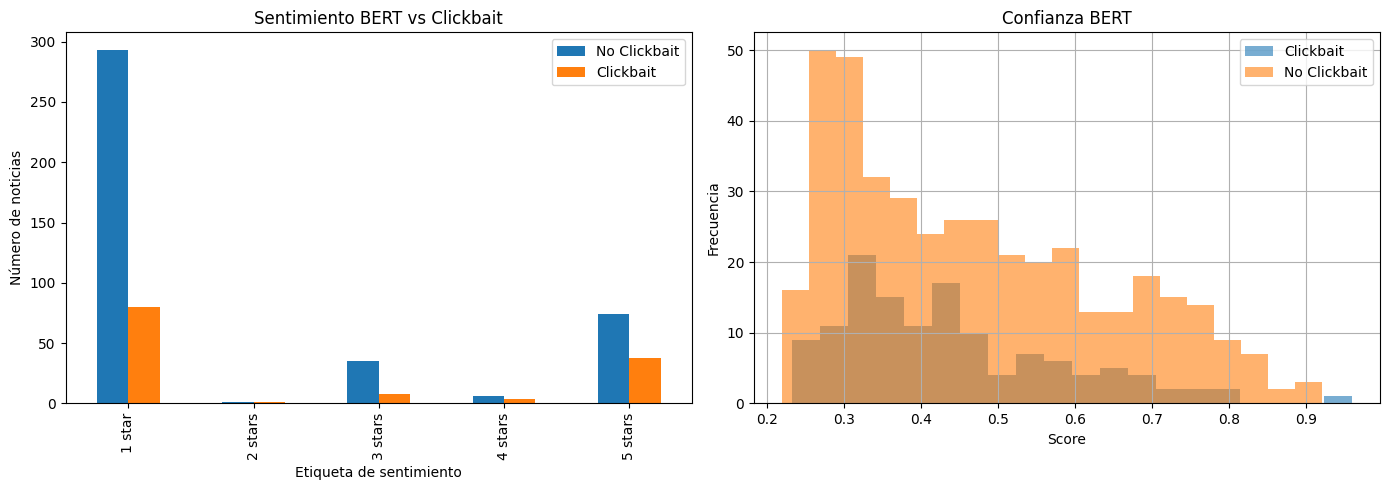

In [13]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

# =========================================================
# RECURSOS NLTK
# =========================================================

nltk.download('stopwords')

# =========================================================
# MODELO BERT MULTILINGÜE
# =========================================================

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0  # GPU
    # device=-1 para CPU
)

# =========================================================
# PREPROCESADO
# =========================================================

stop_words = set(stopwords.words('spanish'))
stemmer = SnowballStemmer('spanish')

def preprocesar_titulo(titulo):

    if not titulo:
        return ""

    palabras = titulo.lower().split()

    palabras_filtradas = [
        stemmer.stem(p)
        for p in palabras
        if p not in stop_words and len(p) > 2
    ]

    return " ".join(palabras_filtradas)

# =========================================================
# ANÁLISIS DE SENTIMIENTO CON BERT
# =========================================================

def analisis_sentimiento_bert(titulo):

    resultado = sentiment_pipeline(
        titulo[:512],
        truncation=True
    )[0]

    return {
        "bert_label": resultado['label'],
        "bert_score": resultado['score']
    }

# =========================================================
# EXTRACCIÓN DEL DATASET
# =========================================================

def extraer_sentimientos(noticias):

    registros = []

    for i, noticia in enumerate(noticias):

        titulo_original = noticia.get("Título", "")
        clickbait = noticia.get("cb", False)

        # Preprocesado
        titulo = preprocesar_titulo(titulo_original)

        # Sentimiento
        bert_feats = analisis_sentimiento_bert(titulo)

        feats = {
            "titulo": titulo_original,
            "titulo_preprocesado": titulo,
            "Clickbait": clickbait,
            **bert_feats
        }

        registros.append(feats)

        if (i + 1) % 100 == 0:
            print(f"Procesados {i + 1}/{len(noticias)}")

    return pd.DataFrame(registros)

# =========================================================
# EJECUCIÓN
# =========================================================

df_sentimientos = extraer_sentimientos(noticias)

# =========================================================
# ESTADÍSTICAS
# =========================================================

print("\n=== DISTRIBUCIÓN DE SENTIMIENTOS ===\n")

print(
    df_sentimientos.groupby(
        ["Clickbait", "bert_label"]
    ).size()
)

# =========================================================
# REPRESENTACIÓN GRÁFICA
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# GRÁFICO 1:
# Distribución de etiquetas de sentimiento
# ---------------------------------------------------------

tabla_sentimientos = pd.crosstab(
    df_sentimientos["bert_label"],
    df_sentimientos["Clickbait"]
)

tabla_sentimientos.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Sentimiento BERT vs Clickbait")
axes[0].set_xlabel("Etiqueta de sentimiento")
axes[0].set_ylabel("Número de noticias")

axes[0].legend([
    "No Clickbait",
    "Clickbait"
])

# ---------------------------------------------------------
# GRÁFICO 2:
# Distribución de confianza del modelo
# ---------------------------------------------------------

df_sentimientos[
    df_sentimientos["Clickbait"] == True
]["bert_score"].hist(
    ax=axes[1],
    alpha=0.6,
    bins=20,
    label="Clickbait"
)

df_sentimientos[
    df_sentimientos["Clickbait"] == False
]["bert_score"].hist(
    ax=axes[1],
    alpha=0.6,
    bins=20,
    label="No Clickbait"
)

axes[1].set_title("Confianza BERT")
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Frecuencia")

axes[1].legend()

plt.tight_layout()
plt.show()

In [111]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer

# =========================================================
# MODELO DE EMBEDDINGS EN ESPAÑOL
# =========================================================

model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

# =========================================================
# EXTRAER TÍTULOS Y ETIQUETAS
# =========================================================

titulos = []
labels = []

for noticia in noticias:

    titulo = noticia.get("Cuerpo", "")
    cb = noticia.get("cb", False)

    titulos.append(titulo)
    labels.append(cb)

# =========================================================
# GENERAR EMBEDDINGS
# =========================================================

embeddings = model.encode(
    titulos,
    show_progress_bar=True,
    batch_size=32
)

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_embeddings = pd.DataFrame(embeddings)

df_embeddings["Clickbait"] = labels
df_embeddings["titulo"] = titulos



Batches: 100%|██████████| 17/17 [00:00<00:00, 34.83it/s]


In [112]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
# =========================================================
# FEATURES Y LABELS
# =========================================================

X = embeddings
y = np.array(labels)

# =========================================================
# SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# MODELO
# =========================================================

clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

clf.fit(X_train, y_train)

# =========================================================
# PREDICCIÓN
# =========================================================

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.76      1.00      0.86        82
        True       0.00      0.00      0.00        26

    accuracy                           0.76       108
   macro avg       0.38      0.50      0.43       108
weighted avg       0.58      0.76      0.66       108



/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


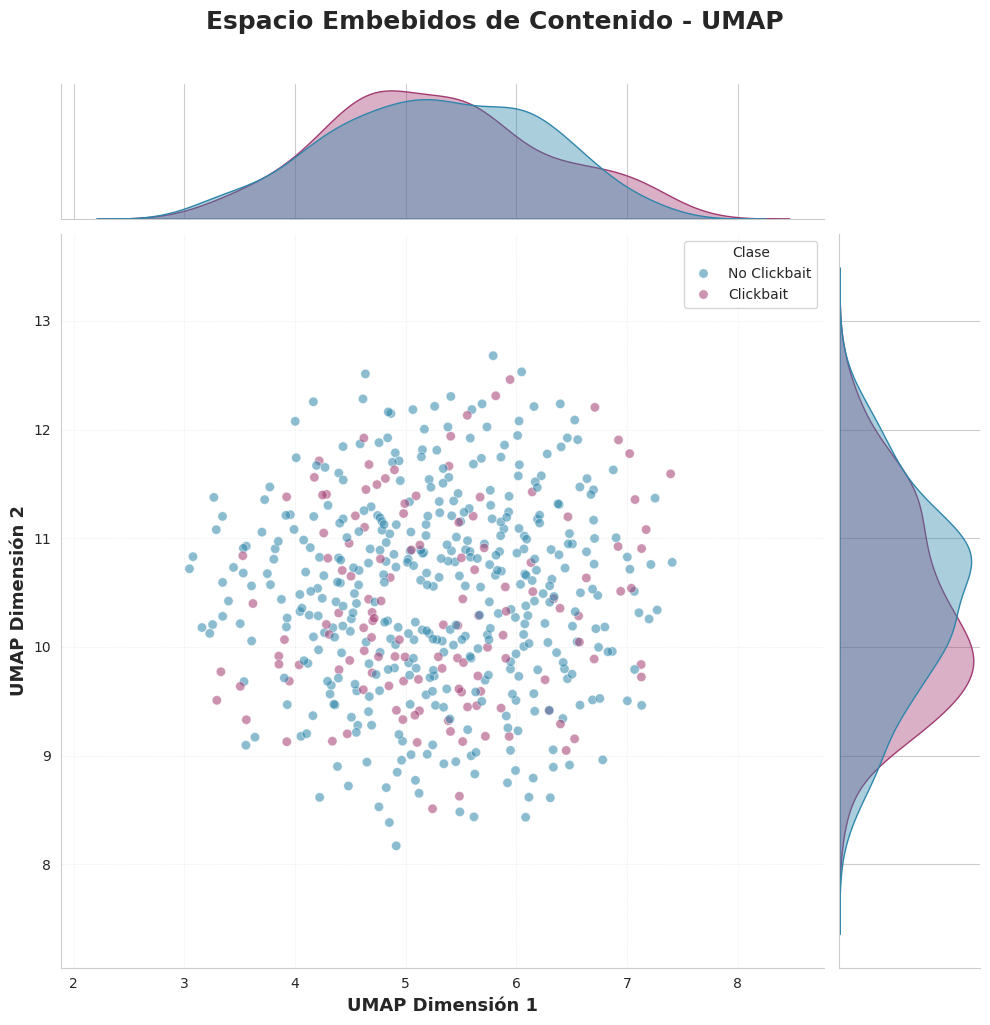

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

# =========================================================
# UMAP
# =========================================================

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

X_umap = reducer.fit_transform(embeddings)

# =========================================================
# DATAFRAME
# =========================================================

df_umap = pd.DataFrame({
    "UMAP 1": X_umap[:, 0],
    "UMAP 2": X_umap[:, 1],
    "Clase": [
        "Clickbait" if x else "No Clickbait"
        for x in labels
    ]
})

# =========================================================
# ESTILO
# =========================================================

sns.set_style("whitegrid")

palette = {
    "No Clickbait": "#2E86AB",
    "Clickbait": "#A23B72"
}

# =========================================================
# JOINTPLOT
# =========================================================

g = sns.jointplot(
    data=df_umap,
    x="UMAP 1",
    y="UMAP 2",
    hue="Clase",
    kind="scatter",
    palette=palette,
    alpha=0.55,
    s=45,
    height=10,
    space=0.15,
    marginal_kws=dict(
        fill=True,
        common_norm=False,
        alpha=0.4
    )
)

# =========================================================
# TÍTULO
# =========================================================

g.fig.suptitle(
    "Espacio Embebidos de Contenido - UMAP",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# =========================================================
# LABELS
# =========================================================

g.set_axis_labels(
    "UMAP Dimensión 1",
    "UMAP Dimensión 2",
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# GRID
# =========================================================

g.ax_joint.grid(
    True,
    alpha=0.3,
    linestyle='--',
    linewidth=0.5
)

# =========================================================
# LIMPIEZA VISUAL
# =========================================================

sns.despine()

plt.tight_layout()
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch

# # --- 1. PREPARAR DATASET ---
# def preparar_dataset(noticias):
#     datos = {
#         "text": [n.get("Título", "") for n in noticias],
#         "label": [1 if n.get("clickbait") else 0 for n in noticias]
#     }
#     dataset = Dataset.from_dict(datos)
#     return dataset.train_test_split(test_size=0.2, seed=42)

# datasets = preparar_dataset(noticias)

# # --- 2. TOKENIZAR ---
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# def tokenize_function(examples):
#     return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# datasets_tokenized = datasets.map(tokenize_function, batched=True)

# # --- 3. FINE-TUNING ---
# model = AutoModelForSequenceClassification.from_pretrained(
#     model_name, 
#     num_labels=2,
#     ignore_mismatched_sizes=True  # AGREGAR ESTO
# )

# training_args = TrainingArguments(
#     output_dir="./bert_clickbait_finetuned",
#     learning_rate=2e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=5,
#     weight_decay=0.01,
#     eval_strategy="epoch",  # CAMBIAR evaluation_strategy -> eval_strategy
#     save_strategy="epoch",
#     load_best_model_at_end=True,
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=datasets_tokenized["train"],
#     eval_dataset=datasets_tokenized["test"],
# )

# trainer.train()
# model.save_pretrained("./bert_clickbait_finetuned")
# tokenizer.save_pretrained("./bert_clickbait_finetuned")

# # --- 4. EXTRAER EMBEDDINGS ---
# model_base = AutoModel.from_pretrained(model_name)

# def obtener_embeddings(textos):
#     inputs = tokenizer(textos, padding=True, truncation=True, max_length=128, return_tensors="pt")
#     with torch.no_grad():
#         outputs = model_base(**inputs)
#     return outputs.last_hidden_state[:, 0, :].cpu().numpy()

# embeddings = obtener_embeddings([n.get("Título", "") for n in noticias])



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2052.06it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

Epoch,Training Loss,Validation Loss
1,No log,0.002895
2,No log,0.000942
3,No log,0.000648
4,No log,0.000544
5,No log,0.000514


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.58s/it]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

In [ ]:
def obtener_embeddings(textos):
    inputs = tokenizer(textos, padding=True, truncation=True, max_length=128, return_tensors="pt")
    with torch.no_grad():
        outputs = model_base(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()

embeddings = obtener_embeddings([n.get("Título", "") for n in noticias])

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


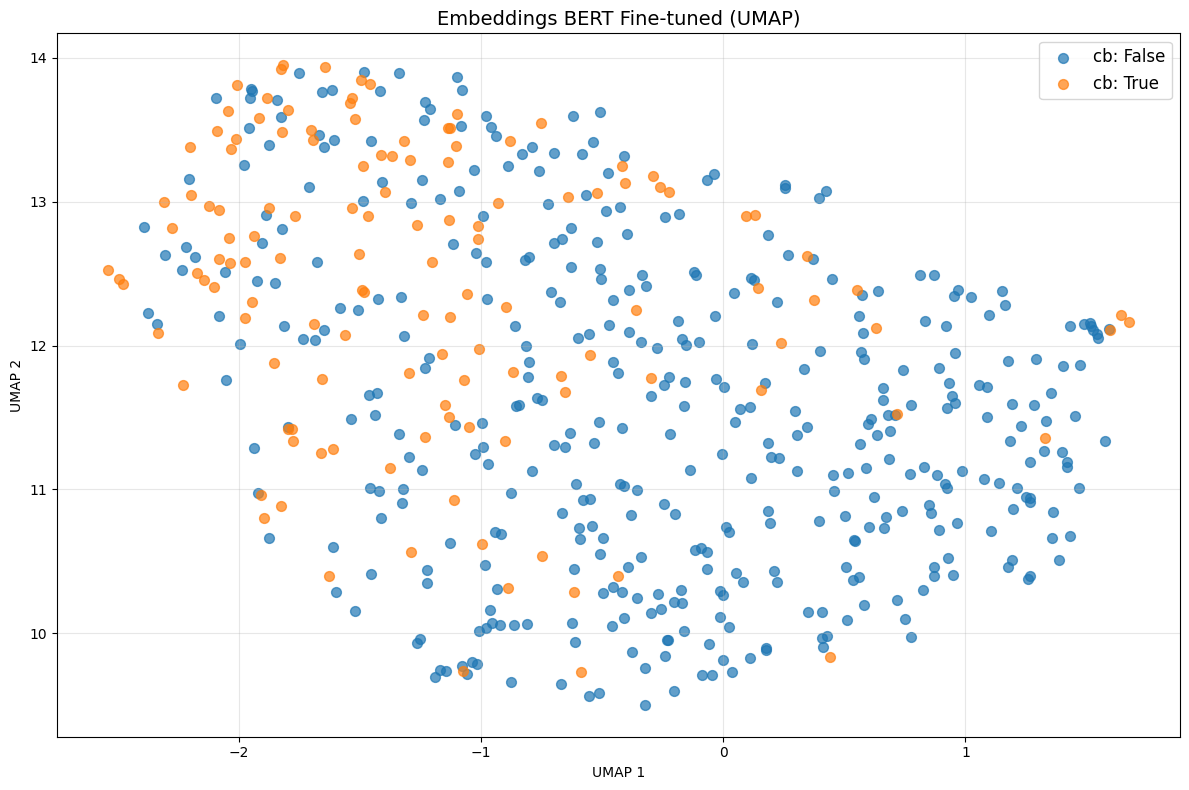

In [48]:
# UMAP
from umap import UMAP
import matplotlib.pyplot as plt

reducer = UMAP(n_components=2, random_state=42, n_neighbors=100, min_dist=0.001)
embeddings_2d = reducer.fit_transform(embeddings)

df_viz = pd.DataFrame({
    "x": embeddings_2d[:, 0],
    "y": embeddings_2d[:, 1],
    "cb": [n.get("cb") for n in noticias]
})

plt.figure(figsize=(12, 8))
for label in [False, True]:
    mask = df_viz["cb"] == label
    plt.scatter(df_viz[mask]["x"], df_viz[mask]["y"], 
               label=f"cb: {label}", alpha=0.7, s=50)
plt.legend(fontsize=12)
plt.title("Embeddings BERT Fine-tuned (UMAP)", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

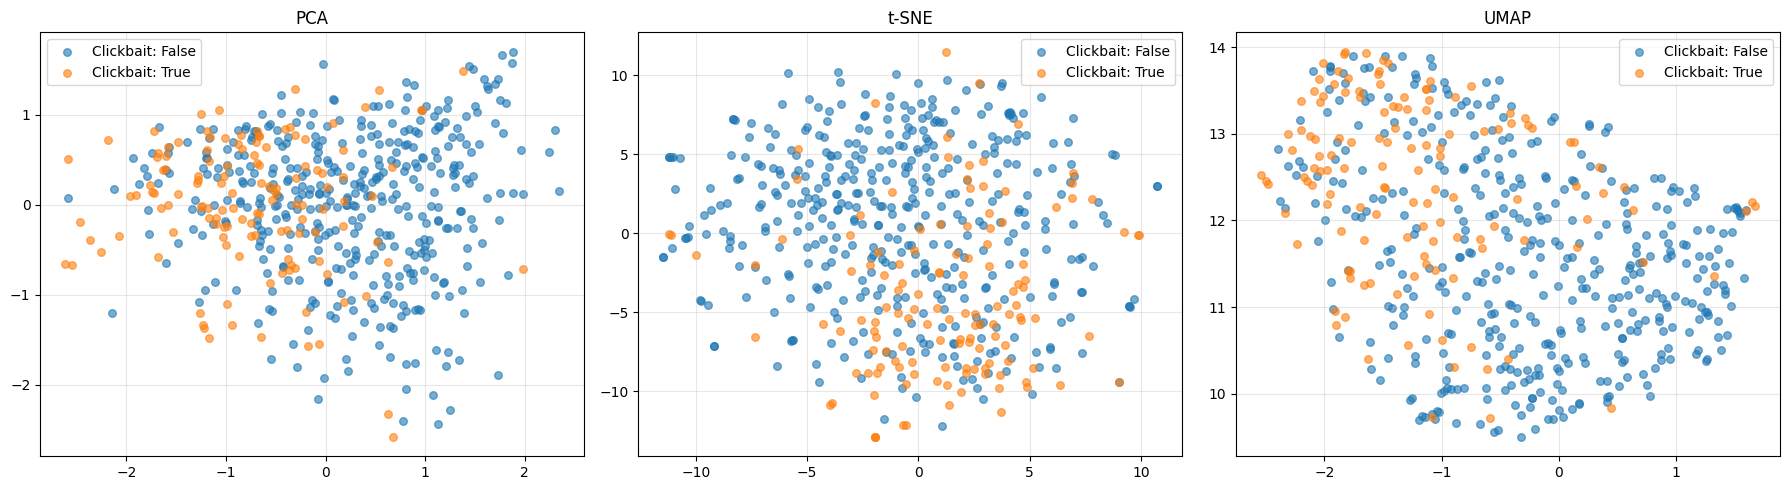

PCA varianza explicada: [0.07627099 0.04780679]


In [56]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# --- PCA ---
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

df_pca = pd.DataFrame({
    "x": embeddings_pca[:, 0],
    "y": embeddings_pca[:, 1],
    "cb": [n.get("cb") for n in noticias]
})

# --- t-SNE ---
tsne = TSNE(n_components=2, random_state=42, perplexity=50)
embeddings_tsne = tsne.fit_transform(embeddings)

df_tsne = pd.DataFrame({
    "x": embeddings_tsne[:, 0],
    "y": embeddings_tsne[:, 1],
    "cb": [n.get("cb") for n in noticias]
})

# --- Graficar los 3 ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df, title) in enumerate([
    (df_pca, "PCA"),
    (df_tsne, "t-SNE"),
    (df_viz, "UMAP")
]):
    for label in [False, True]:
        mask = df["cb"] == label
        axes[idx].scatter(df[mask]["x"], df[mask]["y"], 
                         label=f"Clickbait: {label}", alpha=0.6, s=30)
    axes[idx].set_title(title, fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Varianza explicada (PCA)
print(f"PCA varianza explicada: {pca.explained_variance_ratio_}")

=== MANN-WHITNEY TEST ===

PCA:
  Dim 1 (X): U=11331.00, p-value=0.0000 ***
  Dim 2 (Y): U=26362.00, p-value=0.7835 ns

t-SNE:
  Dim 1 (X): U=34023.00, p-value=0.0000 ***
  Dim 2 (Y): U=13357.00, p-value=0.0000 ***

UMAP:
  Dim 1 (X): U=12392.00, p-value=0.0000 ***
  Dim 2 (Y): U=38409.00, p-value=0.0000 ***



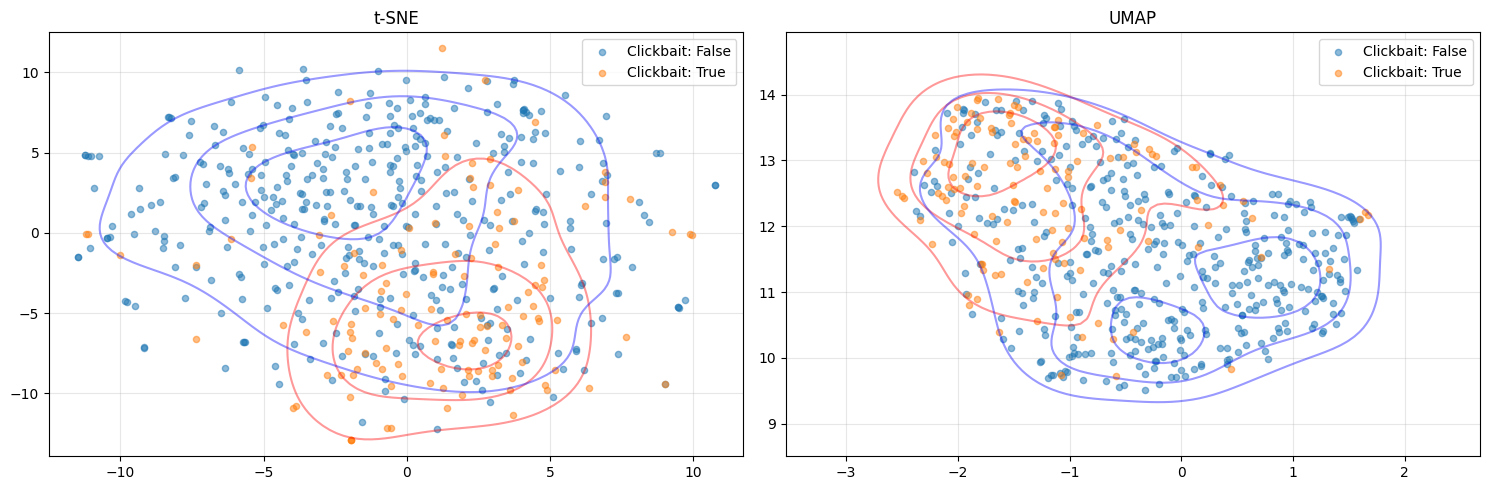

In [60]:
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
import numpy as np

# --- MANN-WHITNEY TEST ---
print("=== MANN-WHITNEY TEST ===\n")

for name, embeddings_2d in [("PCA", embeddings_pca), ("t-SNE", embeddings_tsne), ("UMAP", embeddings_2d)]:
    cb_true = embeddings_2d[[n.get("cb") for n in noticias], :]
    cb_false = embeddings_2d[[not n.get("cb") for n in noticias], :]
    
    stat_x, p_x = mannwhitneyu(cb_true[:, 0], cb_false[:, 0])
    stat_y, p_y = mannwhitneyu(cb_true[:, 1], cb_false[:, 1])
    
    print(f"{name}:")
    print(f"  Dim 1 (X): U={stat_x:.2f}, p-value={p_x:.4f} {'***' if p_x < 0.001 else '**' if p_x < 0.01 else '*' if p_x < 0.05 else 'ns'}")
    print(f"  Dim 2 (Y): U={stat_y:.2f}, p-value={p_y:.4f} {'***' if p_y < 0.001 else '**' if p_y < 0.01 else '*' if p_y < 0.05 else 'ns'}\n")

# --- KDE + Scatter con contours ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for idx, (embeddings_2d, title) in enumerate([
    (embeddings_tsne, "t-SNE"),
    (embeddings_2d, "UMAP")
]):
    ax = axes[idx]
    
    # Scatter points
    for label in [False, True]:
        mask = np.array([n.get("cb") for n in noticias]) == label
        ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                  label=f"Clickbait: {label}", alpha=0.5, s=20)
    
    # KDE contours por grupo
    cb_true = embeddings_2d[[n.get("cb") for n in noticias], :]
    cb_false = embeddings_2d[[not n.get("cb") for n in noticias], :]
    
    # Crear grid
    x_min, x_max = embeddings_2d[:, 0].min() - 1, embeddings_2d[:, 0].max() + 1
    y_min, y_max = embeddings_2d[:, 1].min() - 1, embeddings_2d[:, 1].max() + 1
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    # KDE para cada grupo
    if len(cb_true) > 1:
        kde_true = gaussian_kde(cb_true.T)
        z_true = kde_true(positions).reshape(xx.shape)
        ax.contour(xx, yy, z_true, levels=3, colors='red', alpha=0.4, linewidths=1.5)
    
    if len(cb_false) > 1:
        kde_false = gaussian_kde(cb_false.T)
        z_false = kde_false(positions).reshape(xx.shape)
        ax.contour(xx, yy, z_false, levels=3, colors='blue', alpha=0.4, linewidths=1.5)
    
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

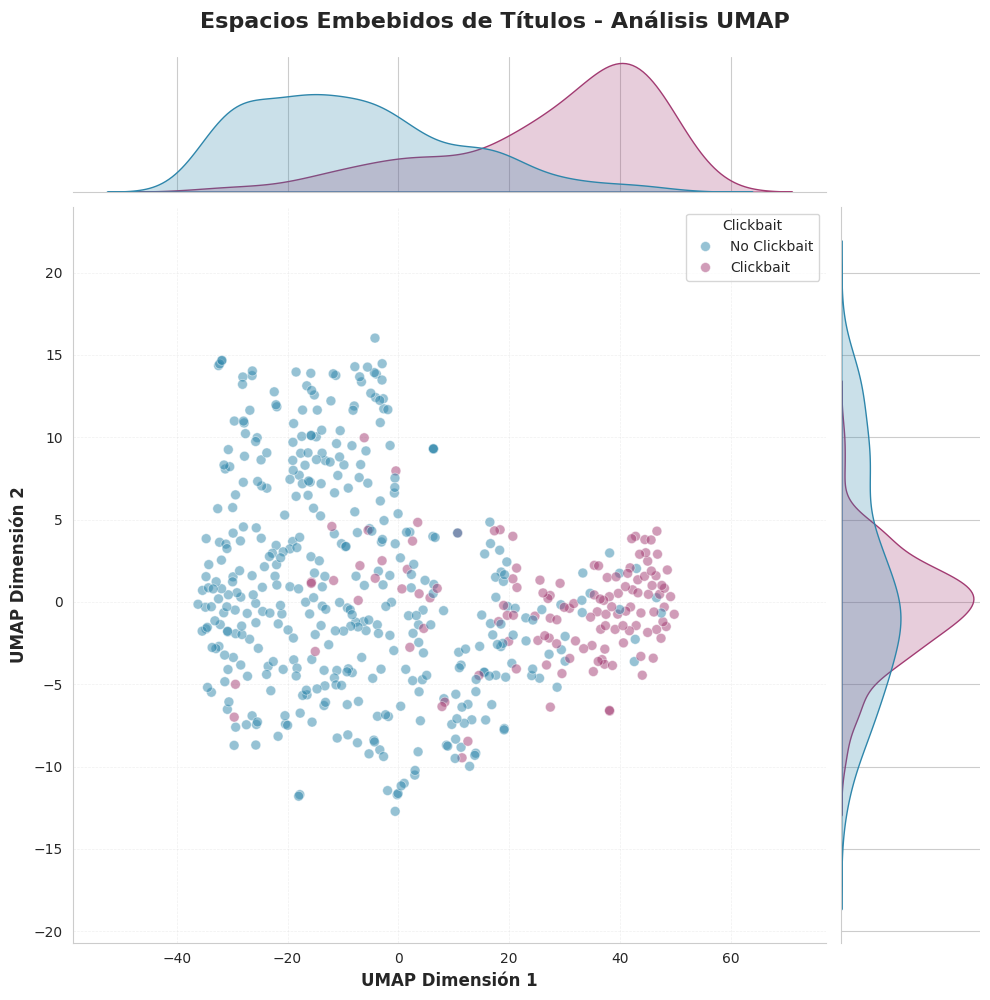

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- PREPARAR DATAFRAME (TÍTULOS) ---
df_umap_titulo = pd.DataFrame({
    "UMAP 1": embeddings_2d[:, 0],
    "UMAP 2": embeddings_2d[:, 1],
    "Clickbait": ["Clickbait" if x else "No Clickbait" for x in [n.get("cb") for n in noticias]]
})

# --- ESTILO PROFESIONAL ---
sns.set_style("whitegrid")
sns.set_palette("husl")

g_titulo = sns.jointplot(
    data=df_umap_titulo,
    x="UMAP 1", 
    y="UMAP 2", 
    hue="Clickbait",
    kind="scatter",  # CAMBIAR A SCATTER
    alpha=0.5, 
    palette={"No Clickbait": "#2E86AB", "Clickbait": "#A23B72"},
    height=10,
    space=0.2,
    marginal_kws=dict(fill=True, common_norm=False),
    s=50  # Tamaño de puntos
)

# --- AGREGAR KDE ENCIMA ---
for label, color in [("No Clickbait", "#2E86AB"), ("Clickbait", "#A23B72")]:
    subset = df_umap_titulo[df_umap_titulo["Clickbait"] == label]
    g_titulo.ax_joint.scatter(subset["UMAP 1"], subset["UMAP 2"], 
                              alpha=0, s=0)  # Invisible, solo para KDE
    


# --- MEJORAR TÍTULOS Y LABELS ---
g_titulo.fig.suptitle(
    "Espacios Embebidos de Títulos - Análisis UMAP", 
    fontsize=16, 
    fontweight='bold', 
    y=0.995
)

g_titulo.set_axis_labels(
    "UMAP Dimensión 1", 
    "UMAP Dimensión 2",
    fontsize=12,
    fontweight='bold'
)

# --- MEJORAR GRID ---
g_titulo.ax_joint.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer
# from datasets import Dataset
# import torch

# # --- 1. PREPARAR DATASET CON CONTENIDO ---
# def preparar_dataset_contenido(noticias):
#     datos = {
#         "text": [n.get("Contenido", "") for n in noticias],
#         "label": [1 if n.get("cb") else 0 for n in noticias]
#     }
#     dataset = Dataset.from_dict(datos)
#     return dataset.train_test_split(test_size=0.2, seed=42)

# datasets_contenido = preparar_dataset_contenido(noticias)

# # --- 2. TOKENIZAR (más largo para contenido) ---
# model_name = "bert-base-multilingual-cased"
# tokenizer_contenido = AutoTokenizer.from_pretrained(model_name)

# def tokenize_function_contenido(examples):
#     return tokenizer_contenido(examples["text"], padding="max_length", truncation=True, max_length=512)

# datasets_tokenized_contenido = datasets_contenido.map(tokenize_function_contenido, batched=True)

# # --- 3. FINE-TUNING ---
# model_contenido = AutoModelForSequenceClassification.from_pretrained(
#     model_name, 
#     num_labels=2,
#     ignore_mismatched_sizes=True
# )

# training_args_contenido = TrainingArguments(
#     output_dir="./bert_clickbait_contenido_finetuned",
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,  # Reducir por tamaño de texto
#     per_device_eval_batch_size=8,
#     num_train_epochs=3,
#     weight_decay=0.01,
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
# )

# trainer_contenido = Trainer(
#     model=model_contenido,
#     args=training_args_contenido,
#     train_dataset=datasets_tokenized_contenido["train"],
#     eval_dataset=datasets_tokenized_contenido["test"],
# )

# trainer_contenido.train()
# model_contenido.save_pretrained("./bert_clickbait_contenido_finetuned")
# tokenizer_contenido.save_pretrained("./bert_clickbait_contenido_finetuned")




Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1683.71it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

Epoch,Training Loss,Validation Loss
1,No log,0.415437
2,No log,0.388705
3,No log,0.401657


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.79it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'ber

Shape embeddings contenido: (540, 768)


In [ ]:
# --- 4. EXTRAER EMBEDDINGS DEL CONTENIDO ---
model_contenido_base = AutoModel.from_pretrained("./bert_clickbait_contenido_finetuned")

def obtener_embeddings_contenido(textos):
    inputs = tokenizer_contenido(textos, padding=True, truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        outputs = model_contenido_base(**inputs)
    return outputs.last_hidden_state[:, 0, :].cpu().numpy()

contenidos = [n.get("Contenido", "") for n in noticias]
embeddings_contenido = obtener_embeddings_contenido(contenidos)

Shape embeddings contenido: (540, 768)

=== MANN-WHITNEY TEST (CONTENIDO) ===

PCA:
  Dim 1 (X): U=48441.00, p-value=0.0000 ***
  Dim 2 (Y): U=24056.00, p-value=0.0787 ns

t-SNE:
  Dim 1 (X): U=48340.00, p-value=0.0000 ***
  Dim 2 (Y): U=24847.00, p-value=0.2115 ns



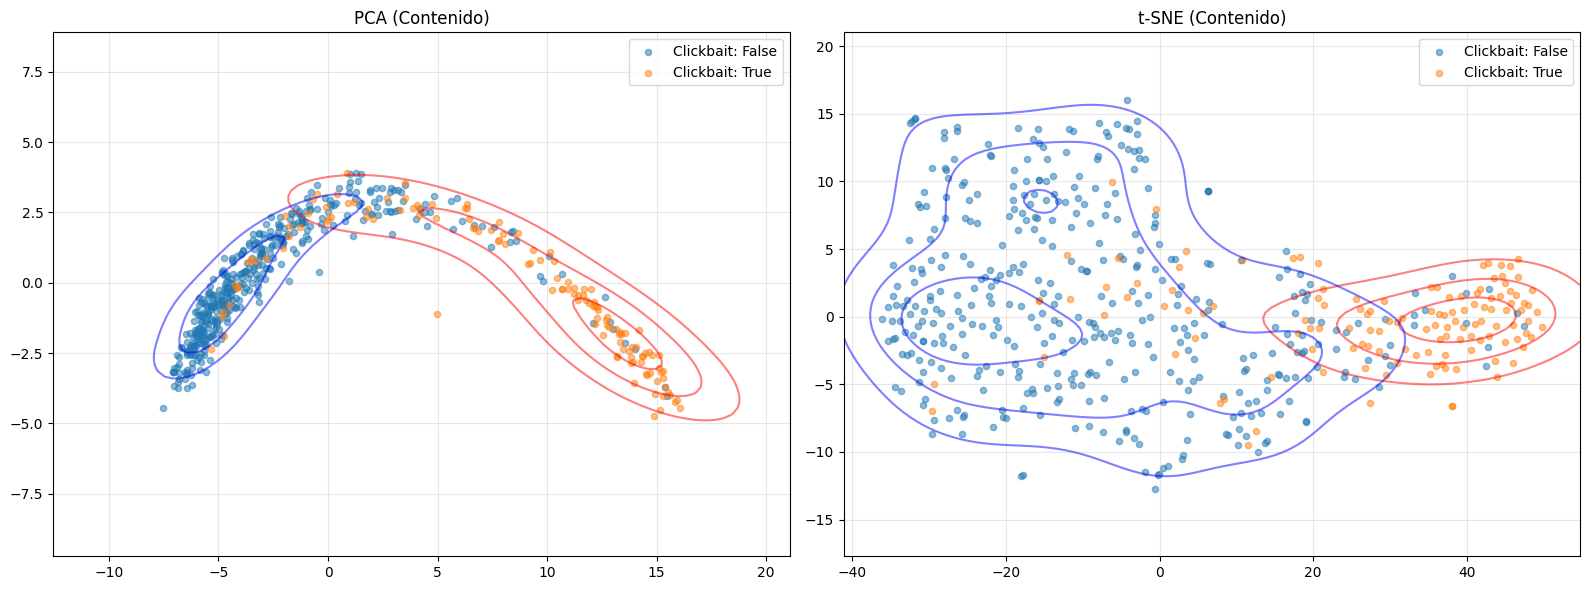

In [ ]:


print(f"Shape embeddings contenido: {embeddings_contenido.shape}")
# --- 5. REDUCCIÓN DE DIMENSIONALIDAD ---
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

pca_cont = PCA(n_components=2, random_state=42)
embeddings_pca_cont = pca_cont.fit_transform(embeddings_contenido)

tsne_cont = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_tsne_cont = tsne_cont.fit_transform(embeddings_contenido)

# --- 6. VISUALIZACIÓN ---
from scipy.stats import mannwhitneyu
import numpy as np

print("\n=== MANN-WHITNEY TEST (CONTENIDO) ===\n")

for embeddings_2d, title in [
    (embeddings_pca_cont, "PCA"),
    (embeddings_tsne_cont, "t-SNE")
]:
    cb_true = embeddings_2d[[n.get("cb") for n in noticias], :]
    cb_false = embeddings_2d[[not n.get("cb") for n in noticias], :]
    
    stat_x, p_x = mannwhitneyu(cb_true[:, 0], cb_false[:, 0])
    stat_y, p_y = mannwhitneyu(cb_true[:, 1], cb_false[:, 1])
    
    print(f"{title}:")
    print(f"  Dim 1 (X): U={stat_x:.2f}, p-value={p_x:.4f} {'***' if p_x < 0.001 else '**' if p_x < 0.01 else '*' if p_x < 0.05 else 'ns'}")
    print(f"  Dim 2 (Y): U={stat_y:.2f}, p-value={p_y:.4f} {'***' if p_y < 0.001 else '**' if p_y < 0.01 else '*' if p_y < 0.05 else 'ns'}\n")

# --- 7. GRÁFICA t-SNE CON KDE ---
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (embeddings_2d, title) in enumerate([
    (embeddings_pca_cont, "PCA"),
    (embeddings_tsne_cont, "t-SNE")
]):
    ax = axes[idx]
    
    for label in [False, True]:
        mask = np.array([n.get("cb") for n in noticias]) == label
        ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                  label=f"Clickbait: {label}", alpha=0.5, s=20)
    
    cb_true = embeddings_2d[[n.get("cb") for n in noticias], :]
    cb_false = embeddings_2d[[not n.get("cb") for n in noticias], :]
    
    x_min, x_max = embeddings_2d[:, 0].min() - 5, embeddings_2d[:, 0].max() + 5
    y_min, y_max = embeddings_2d[:, 1].min() - 5, embeddings_2d[:, 1].max() + 5
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    if len(cb_true) > 1:
        kde_true = gaussian_kde(cb_true.T)
        z_true = kde_true(positions).reshape(xx.shape)
        ax.contour(xx, yy, z_true, levels=3, colors='red', alpha=0.5, linewidths=1.5)
    
    if len(cb_false) > 1:
        kde_false = gaussian_kde(cb_false.T)
        z_false = kde_false(positions).reshape(xx.shape)
        ax.contour(xx, yy, z_false, levels=3, colors='blue', alpha=0.5, linewidths=1.5)
    
    ax.set_title(f"{title} (Contenido)", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape embeddings UMAP contenido: (540, 2)

=== MANN-WHITNEY TEST (UMAP CONTENIDO) ===

UMAP:
  Dim 1 (X): U=47993.00, p-value=0.0000 ***
  Dim 2 (Y): U=43565.00, p-value=0.0000 ***



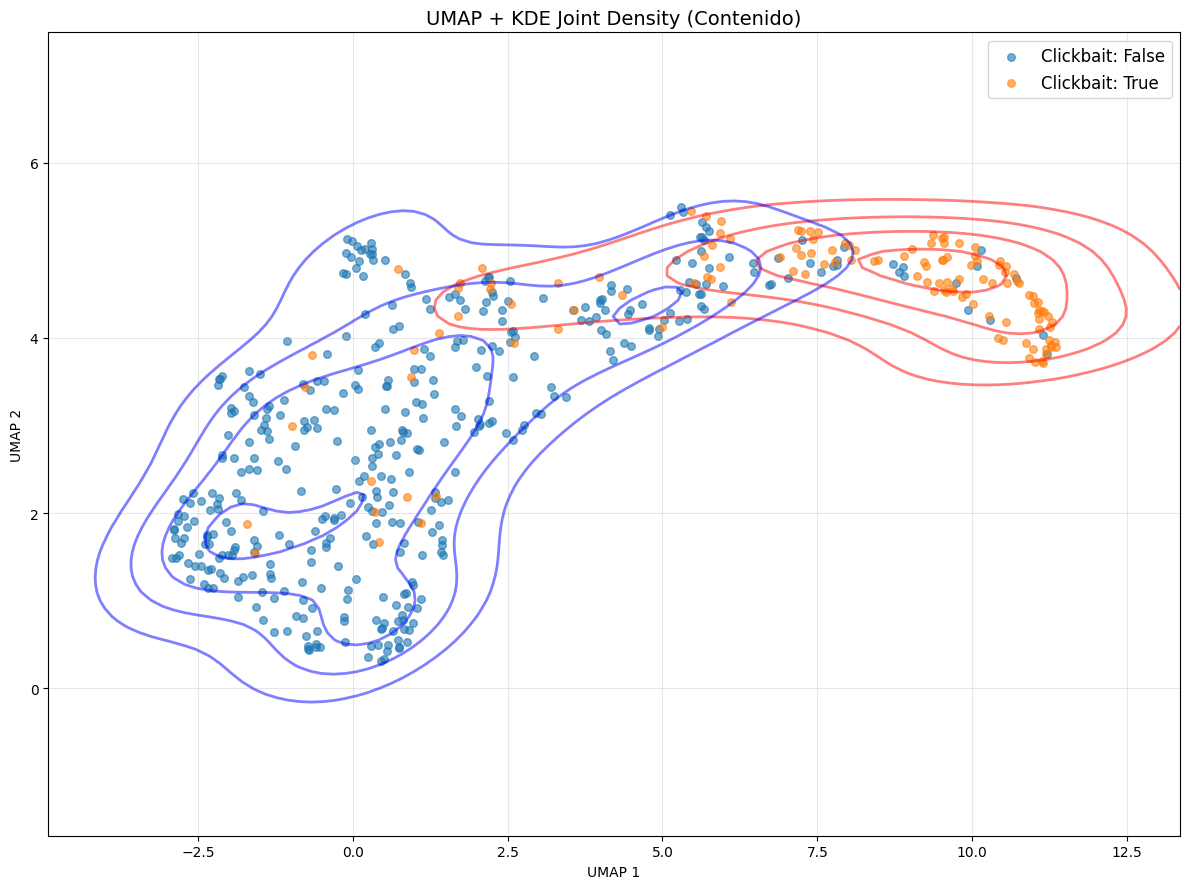

Distancia entre centroides (UMAP): 6.632


In [67]:
from umap import UMAP

# --- UMAP CONTENIDO ---
umap_cont = UMAP(n_components=2, random_state=42)
embeddings_umap_cont = umap_cont.fit_transform(embeddings_contenido)

print(f"Shape embeddings UMAP contenido: {embeddings_umap_cont.shape}")

# --- MANN-WHITNEY TEST UMAP ---
from scipy.stats import mannwhitneyu
import numpy as np

cb_true = embeddings_umap_cont[[n.get("cb") for n in noticias], :]
cb_false = embeddings_umap_cont[[not n.get("cb") for n in noticias], :]

stat_x, p_x = mannwhitneyu(cb_true[:, 0], cb_false[:, 0])
stat_y, p_y = mannwhitneyu(cb_true[:, 1], cb_false[:, 1])

print("\n=== MANN-WHITNEY TEST (UMAP CONTENIDO) ===\n")
print(f"UMAP:")
print(f"  Dim 1 (X): U={stat_x:.2f}, p-value={p_x:.4f} {'***' if p_x < 0.001 else '**' if p_x < 0.01 else '*' if p_x < 0.05 else 'ns'}")
print(f"  Dim 2 (Y): U={stat_y:.2f}, p-value={p_y:.4f} {'***' if p_y < 0.001 else '**' if p_y < 0.01 else '*' if p_y < 0.05 else 'ns'}\n")

# --- GRÁFICA UMAP CON KDE ---
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

# Scatter points
for label in [False, True]:
    mask = np.array([n.get("cb") for n in noticias]) == label
    plt.scatter(embeddings_umap_cont[mask, 0], embeddings_umap_cont[mask, 1], 
               label=f"Clickbait: {label}", alpha=0.6, s=30)

# KDE contours
x_min, x_max = embeddings_umap_cont[:, 0].min() - 2, embeddings_umap_cont[:, 0].max() + 2
y_min, y_max = embeddings_umap_cont[:, 1].min() - 2, embeddings_umap_cont[:, 1].max() + 2
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])

kde_true = gaussian_kde(cb_true.T)
z_true = kde_true(positions).reshape(xx.shape)
plt.contour(xx, yy, z_true, levels=4, colors='red', alpha=0.5, linewidths=2)

kde_false = gaussian_kde(cb_false.T)
z_false = kde_false(positions).reshape(xx.shape)
plt.contour(xx, yy, z_false, levels=4, colors='blue', alpha=0.5, linewidths=2)

plt.title("UMAP + KDE Joint Density (Contenido)", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Distancia entre centroides
from scipy.spatial.distance import euclidean

centroid_true = cb_true.mean(axis=0)
centroid_false = cb_false.mean(axis=0)
dist = euclidean(centroid_true, centroid_false)

print(f"Distancia entre centroides (UMAP): {dist:.3f}")

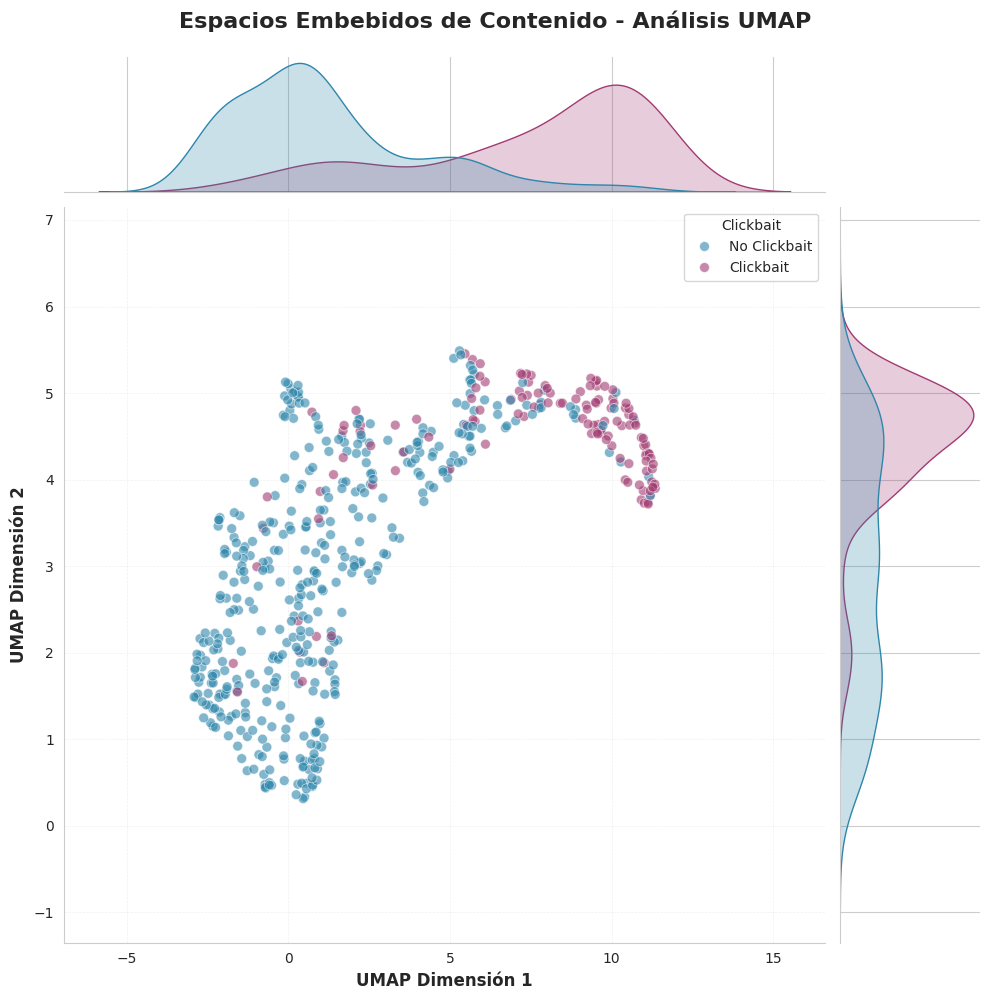

In [115]:

# --- PREPARAR DATAFRAME ---
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- PREPARAR DATAFRAME ---
df_umap = pd.DataFrame({
    "UMAP 1": embeddings_umap_cont[:, 0],
    "UMAP 2": embeddings_umap_cont[:, 1],
    "Clickbait": ["Clickbait" if x else "No Clickbait" for x in [n.get("cb") for n in noticias]]
})

# --- ESTILO PROFESIONAL ---
sns.set_style("whitegrid")
sns.set_palette("husl")

g = sns.jointplot(
    data=df_umap,
    x="UMAP 1", 
    y="UMAP 2", 
    hue="Clickbait",
    kind="scatter",
    alpha=0.6, 
    palette={"No Clickbait": "#2E86AB", "Clickbait": "#A23B72"},
    height=10,
    space=0.2,
    marginal_kws=dict(fill=True, common_norm=False),
    s=50
)
for label, color in [("No Clickbait", "#2E86AB"), ("Clickbait", "#A23B72")]:
    subset = df_umap[df_umap["Clickbait"] == label]
    g.ax_joint.scatter(subset["UMAP 1"], subset["UMAP 2"], 
                              alpha=0, s=0)  # Invisible, solo para KDE
    
# --- MEJORAR TÍTULOS Y LABELS ---
g.fig.suptitle(
    "Espacios Embebidos de Contenido - Análisis UMAP", 
    fontsize=16, 
    fontweight='bold', 
    y=0.995
)

g.set_axis_labels(
    "UMAP Dimensión 1", 
    "UMAP Dimensión 2",
    fontsize=12,
    fontweight='bold'
)


# --- MEJORAR GRID ---
g.ax_joint.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Periódicos encontrados: ['Mediterráneo Digital', 'Huffingtonpost', 'ElDiario', 'El Confidencial', '20minutos', 'La Vanguardia', 'okdiario', 'RTVE', 'ABC']


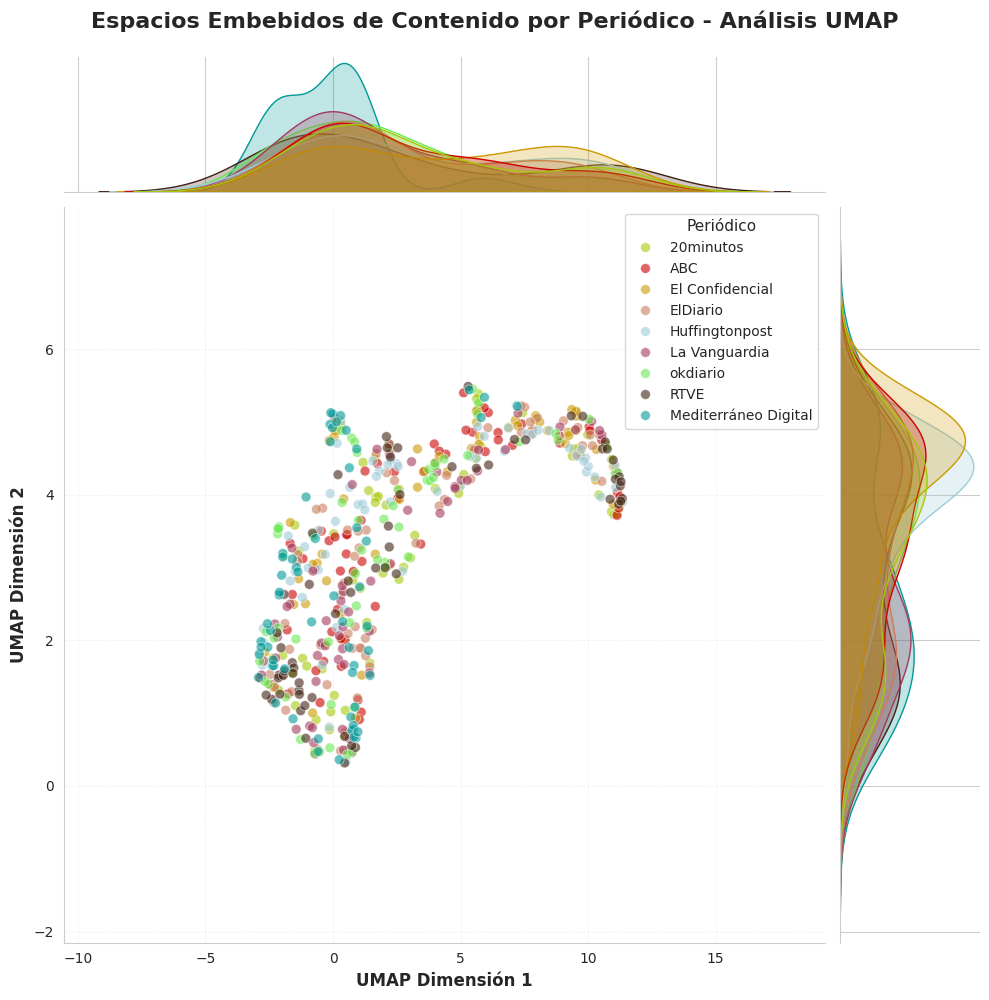

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- OBTENER PERIÓDICOS ÚNICOS Y CREAR PALETA ---
periodicos = list(set([n.get("Periódico") for n in noticias]))
print(f"Periódicos encontrados: {periodicos}")

# Paleta de colores por periódico (ajusta según tus periódicos)
colores_periodicos = {
    "El País": "#0066CC",
    "El Mundo": "#FF6600",
    "ABC": "#CC0000",
    "La Razón": "#006633",
    "20 Minutos": "#0DCE1D",
    "Público": "#9900CC",
    "eldiario.es": "#00CCFF",
    "Huffington Post": "#FF00AA",
    "El Confidencial": "#CC9900",
    "Mediterráneo Digital": "#009999"
}

# Asignar colores (agregar más si es necesario)
for periodico in periodicos:
    if periodico not in colores_periodicos:
        colores_periodicos[periodico] = f"#{np.random.randint(0, 0xFFFFFF):06x}"

# --- PREPARAR DATAFRAME ---
df_umap = pd.DataFrame({
    "UMAP 1": embeddings_umap_cont[:, 0],
    "UMAP 2": embeddings_umap_cont[:, 1],
    "Periódico": [n.get("Periódico") for n in noticias]
})

# --- ESTILO PROFESIONAL ---
sns.set_style("whitegrid")

g = sns.jointplot(
    data=df_umap,
    x="UMAP 1", 
    y="UMAP 2", 
    hue="Periódico",
    kind="scatter",
    alpha=0.6, 
    palette=colores_periodicos,
    height=10,
    space=0.2,
    marginal_kws=dict(fill=True, common_norm=False),
    s=50
)

# --- MEJORAR TÍTULOS Y LABELS ---
g.fig.suptitle(
    "Espacios Embebidos de Contenido por Periódico - Análisis UMAP", 
    fontsize=16, 
    fontweight='bold', 
    y=0.995
)

g.set_axis_labels(
    "UMAP Dimensión 1", 
    "UMAP Dimensión 2",
    fontsize=12,
    fontweight='bold'
)

# --- MEJORAR LEYENDA ---
handles = g.ax_joint.get_legend_handles_labels()[0]
labels = g.ax_joint.get_legend_handles_labels()[1]
g.ax_joint.legend(
    handles, labels,
    title="Periódico",
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
)

# --- MEJORAR GRID ---
g.ax_joint.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Periódicos encontrados: ['Mediterráneo Digital', 'Huffingtonpost', 'ElDiario', 'El Confidencial', '20minutos', 'La Vanguardia', 'okdiario', 'RTVE', 'ABC']


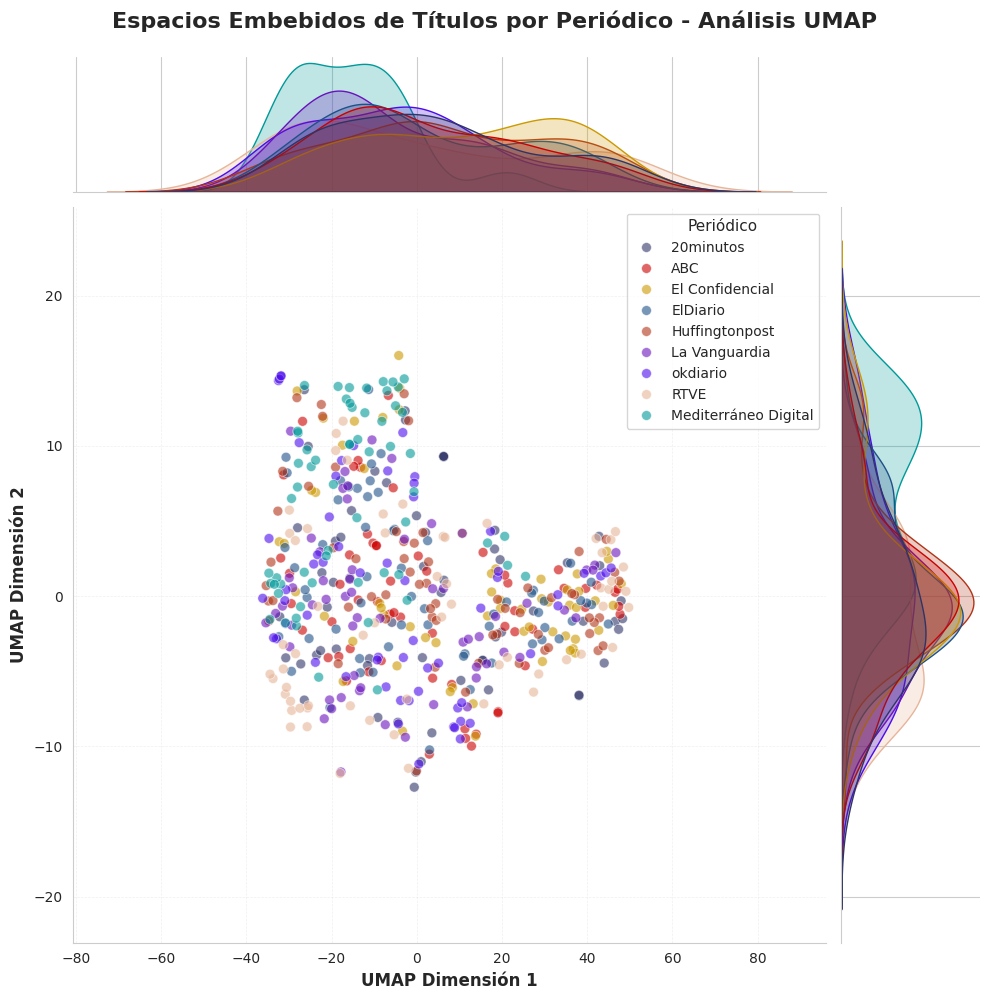

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- OBTENER PERIÓDICOS ÚNICOS Y CREAR PALETA ---
periodicos = list(set([n.get("Periódico") for n in noticias]))
print(f"Periódicos encontrados: {periodicos}")

# Paleta de colores por periódico (ajusta según tus periódicos)
colores_periodicos = {
    "El País": "#0066CC",
    "El Mundo": "#FF6600",
    "ABC": "#CC0000",
    "La Razón": "#006633",
    "20 Minutos": "#0DCE1D",
    "Público": "#9900CC",
    "eldiario.es": "#00CCFF",
    "Huffington Post": "#FF00AA",
    "El Confidencial": "#CC9900",
    "Mediterráneo Digital": "#009999"
}

# Asignar colores (agregar más si es necesario)
for periodico in periodicos:
    if periodico not in colores_periodicos:
        colores_periodicos[periodico] = f"#{np.random.randint(0, 0xFFFFFF):06x}"

# --- PREPARAR DATAFRAME TÍTULO ---
df_umap_titulo = pd.DataFrame({
    "UMAP 1": embeddings_2d[:, 0],
    "UMAP 2": embeddings_2d[:, 1],
    "Periódico": [n.get("Periódico") for n in noticias]
})

# --- ESTILO PROFESIONAL ---
sns.set_style("whitegrid")

g_titulo = sns.jointplot(
    data=df_umap_titulo,
    x="UMAP 1", 
    y="UMAP 2", 
    hue="Periódico",
    kind="scatter",
    alpha=0.6, 
    palette=colores_periodicos,
    height=10,
    space=0.2,
    marginal_kws=dict(fill=True, common_norm=False),
    s=50
)

# --- MEJORAR TÍTULOS Y LABELS ---
g_titulo.fig.suptitle(
    "Espacios Embebidos de Títulos por Periódico - Análisis UMAP", 
    fontsize=16, 
    fontweight='bold', 
    y=0.995
)

g_titulo.set_axis_labels(
    "UMAP Dimensión 1", 
    "UMAP Dimensión 2",
    fontsize=12,
    fontweight='bold'
)

# --- MEJORAR LEYENDA ---
handles = g_titulo.ax_joint.get_legend_handles_labels()[0]
labels = g_titulo.ax_joint.get_legend_handles_labels()[1]
g_titulo.ax_joint.legend(
    handles, labels,
    title="Periódico",
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
)

# --- MEJORAR GRID ---
g_titulo.ax_joint.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Categorías encontradas: ['Internacional', 'Nacional', 'Cultura']


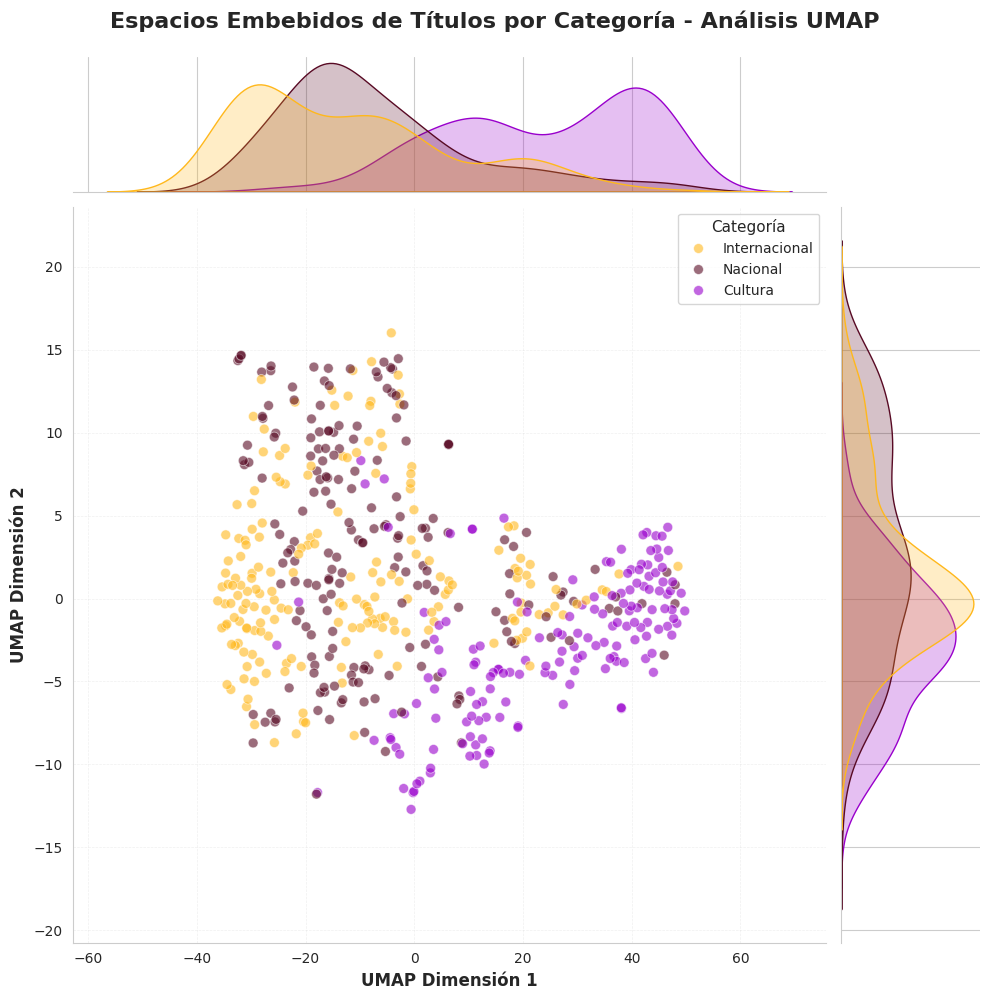

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- OBTENER CATEGORÍAS ÚNICAS Y CREAR PALETA ---
categorias = list(set([n.get("Categoría") for n in noticias]))
print(f"Categorías encontradas: {categorias}")



# Asignar colores (agregar más si es necesario)
for categoria in categorias:
    if categoria not in colores_categorias:
        colores_categorias[categoria] = f"#{np.random.randint(0, 0xFFFFFF):06x}"

# --- PREPARAR DATAFRAME TÍTULO ---
df_umap_titulo = pd.DataFrame({
    "UMAP 1": embeddings_2d[:, 0],
    "UMAP 2": embeddings_2d[:, 1],
    "Categoría": [n.get("Categoría") for n in noticias]
})

# --- ESTILO PROFESIONAL ---
sns.set_style("whitegrid")

g_titulo = sns.jointplot(
    data=df_umap_titulo,
    x="UMAP 1", 
    y="UMAP 2", 
    hue="Categoría",
    kind="scatter",
    alpha=0.6, 
    palette=colores_categorias,
    height=10,
    space=0.2,
    marginal_kws=dict(fill=True, common_norm=False),
    s=50
)

# --- MEJORAR TÍTULOS Y LABELS ---
g_titulo.fig.suptitle(
    "Espacios Embebidos de Títulos por Categoría - Análisis UMAP", 
    fontsize=16, 
    fontweight='bold', 
    y=0.995
)

g_titulo.set_axis_labels(
    "UMAP Dimensión 1", 
    "UMAP Dimensión 2",
    fontsize=12,
    fontweight='bold'
)

# --- MEJORAR LEYENDA ---
handles = g_titulo.ax_joint.get_legend_handles_labels()[0]
labels = g_titulo.ax_joint.get_legend_handles_labels()[1]
g_titulo.ax_joint.legend(
    handles, labels,
    title="Categoría",
    title_fontsize=11,
    fontsize=10,
    loc='upper right',

)

# --- MEJORAR GRID ---
g_titulo.ax_joint.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig("img/UMAP_fine_tuning_titulo_categoria.png", dpi=300)  # Guardar figura con alta resolución
plt.show()

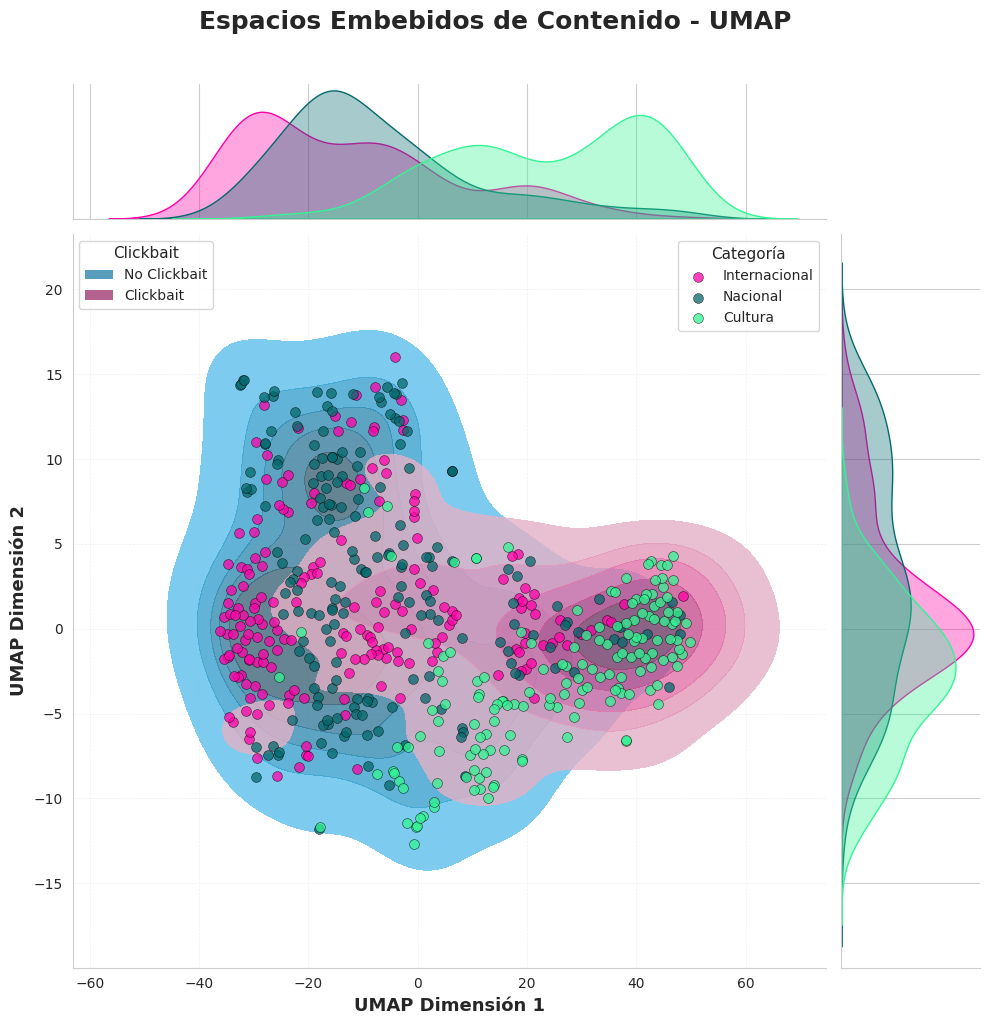

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================
# CATEGORÍAS
# =========================================================

categorias = list(set([n.get("Categoría") for n in noticias]))

colores_categorias = {
    "Cultura": "#32F593",
    "Nacional": "#04696D",
    "Internacional": "#FF00AA",
}

for categoria in categorias:
    if categoria not in colores_categorias:
        colores_categorias[categoria] = f"#{np.random.randint(0, 0xFFFFFF):06x}"

# =========================================================
# DATAFRAME
# =========================================================

df = pd.DataFrame({
    "UMAP 1": embeddings_2d[:, 0],
    "UMAP 2": embeddings_2d[:, 1],
    "Clickbait": [
        "Clickbait" if x else "No Clickbait"
        for x in [n.get("cb") for n in noticias]
    ],
    "Categoría": [n.get("Categoría") for n in noticias]
})

# =========================================================
# ESTILO
# =========================================================

sns.set_style("whitegrid")

# =========================================================
# JOINTGRID
# =========================================================

g = sns.JointGrid(
    data=df,
    x="UMAP 1",
    y="UMAP 2",
    height=10,
    space=0.15
)

# =========================================================
# KDE FONDO (CLICKBAIT)
# =========================================================

palette_cb = {
    "No Clickbait": "#2E86AB",
    "Clickbait": "#A23B72"
}

for cb in ["No Clickbait", "Clickbait"]:

    subset = df[df["Clickbait"] == cb]

    sns.kdeplot(
        data=subset,
        x="UMAP 1",
        y="UMAP 2",
        fill=True,
        alpha=0.8,
        levels=6,
        color=palette_cb[cb],
        ax=g.ax_joint
    )

# =========================================================
# SCATTER POR CATEGORÍA
# =========================================================

for categoria in categorias:

    subset = df[df["Categoría"] == categoria]

    g.ax_joint.scatter(
        subset["UMAP 1"],
        subset["UMAP 2"],
        label=categoria,
        alpha=0.75,
        s=50,
        color=colores_categorias[categoria],
        edgecolors='black',
        linewidth=0.4
    )

# =========================================================
# MARGINALES POR CATEGORÍA
# =========================================================

for categoria in categorias:

    subset = df[df["Categoría"] == categoria]

    sns.kdeplot(
        data=subset,
        x="UMAP 1",
        fill=True,
        alpha=0.35,
        color=colores_categorias[categoria],
        ax=g.ax_marg_x
    )

    sns.kdeplot(
        data=subset,
        y="UMAP 2",
        fill=True,
        alpha=0.35,
        color=colores_categorias[categoria],
        ax=g.ax_marg_y
    )

# =========================================================
# TÍTULO
# =========================================================

g.fig.suptitle(
    "Espacios Embebidos de Títulos - UMAP",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# =========================================================
# LABELS
# =========================================================

g.set_axis_labels(
    "UMAP Dimensión 1",
    "UMAP Dimensión 2",
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# LEYENDA
# =========================================================

legend_cat = g.ax_joint.legend(
    title="Categoría",
    fontsize=10,
    title_fontsize=11,
    loc='upper right',
    frameon=True
)

g.ax_joint.add_artist(legend_cat)
handles_cb = [
    Patch(facecolor="#2E86AB", edgecolor='none', alpha=0.8,
          label="No Clickbait"),
    
    Patch(facecolor="#A23B72", edgecolor='none', alpha=0.8,
          label="Clickbait")
]

legend_cb = g.ax_joint.legend(
    handles=handles_cb,
    title="Clickbait",
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    frameon=True
)
# =========================================================
# GRID
# =========================================================

g.ax_joint.grid(
    True,
    alpha=0.3,
    linestyle='--',
    linewidth=0.5
)

sns.despine()

plt.tight_layout()
plt.savefig("img/UMAP_fine_tuning_titulo_categoria.png", dpi=300)  # Guardar figura con alta resolución
plt.show()

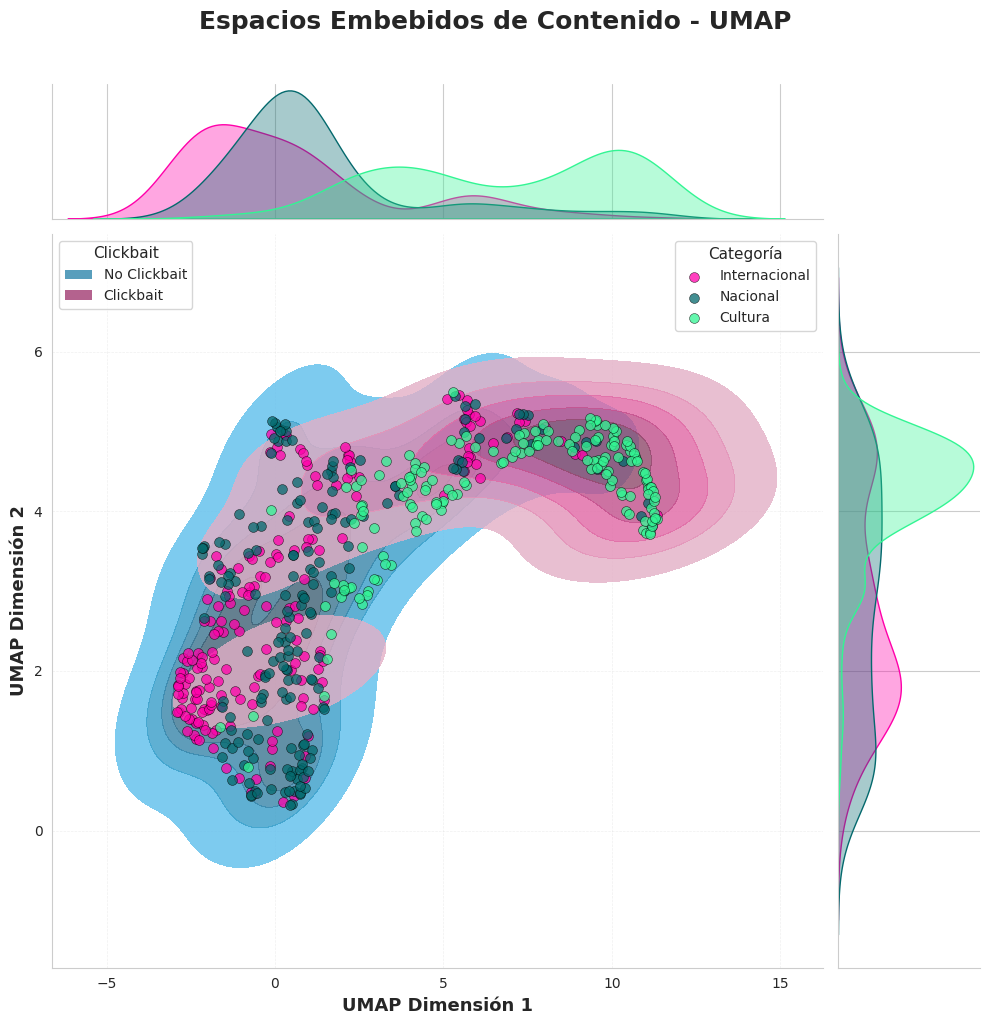

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================================================
# CATEGORÍAS
# =========================================================

categorias = list(set([n.get("Categoría") for n in noticias]))

colores_categorias = {
    "Cultura": "#32F593",
    "Nacional": "#04696D",
    "Internacional": "#FF00AA",
}

for categoria in categorias:
    if categoria not in colores_categorias:
        colores_categorias[categoria] = f"#{np.random.randint(0, 0xFFFFFF):06x}"

# =========================================================
# DATAFRAME
# =========================================================

df = pd.DataFrame({
    "UMAP 1": embeddings_umap_cont[:, 0],
    "UMAP 2": embeddings_umap_cont[:, 1],
    "Clickbait": [
        "Clickbait" if x else "No Clickbait"
        for x in [n.get("cb") for n in noticias]
    ],
    "Categoría": [n.get("Categoría") for n in noticias]
})

# =========================================================
# ESTILO
# =========================================================

sns.set_style("whitegrid")

# =========================================================
# JOINTGRID
# =========================================================

g = sns.JointGrid(
    data=df,
    x="UMAP 1",
    y="UMAP 2",
    height=10,
    space=0.15
)

# =========================================================
# KDE FONDO (CLICKBAIT)
# =========================================================

palette_cb = {
    "No Clickbait": "#2E86AB",
    "Clickbait": "#A23B72"
}

for cb in ["No Clickbait", "Clickbait"]:

    subset = df[df["Clickbait"] == cb]

    sns.kdeplot(
        data=subset,
        x="UMAP 1",
        y="UMAP 2",
        fill=True,
        alpha=0.8,
        levels=6,
        color=palette_cb[cb],
        ax=g.ax_joint
    )

# =========================================================
# SCATTER POR CATEGORÍA
# =========================================================

for categoria in categorias:

    subset = df[df["Categoría"] == categoria]

    g.ax_joint.scatter(
        subset["UMAP 1"],
        subset["UMAP 2"],
        label=categoria,
        alpha=0.75,
        s=50,
        color=colores_categorias[categoria],
        edgecolors='black',
        linewidth=0.4
    )

# =========================================================
# MARGINALES POR CATEGORÍA
# =========================================================

for categoria in categorias:

    subset = df[df["Categoría"] == categoria]

    sns.kdeplot(
        data=subset,
        x="UMAP 1",
        fill=True,
        alpha=0.35,
        color=colores_categorias[categoria],
        ax=g.ax_marg_x
    )

    sns.kdeplot(
        data=subset,
        y="UMAP 2",
        fill=True,
        alpha=0.35,
        color=colores_categorias[categoria],
        ax=g.ax_marg_y
    )

# =========================================================
# TÍTULO
# =========================================================

g.fig.suptitle(
    "Espacios Embebidos de Contenido - UMAP",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# =========================================================
# LABELS
# =========================================================

g.set_axis_labels(
    "UMAP Dimensión 1",
    "UMAP Dimensión 2",
    fontsize=13,
    fontweight='bold'
)

# =========================================================
# LEYENDA
# =========================================================

legend_cat = g.ax_joint.legend(
    title="Categoría",
    fontsize=10,
    title_fontsize=11,
    loc='upper right',
    frameon=True
)

g.ax_joint.add_artist(legend_cat)
handles_cb = [
    Patch(facecolor="#2E86AB", edgecolor='none', alpha=0.8,
          label="No Clickbait"),
    
    Patch(facecolor="#A23B72", edgecolor='none', alpha=0.8,
          label="Clickbait")
]

legend_cb = g.ax_joint.legend(
    handles=handles_cb,
    title="Clickbait",
    fontsize=10,
    title_fontsize=11,
    loc='upper left',
    frameon=True
)
# =========================================================
# GRID
# =========================================================

g.ax_joint.grid(
    True,
    alpha=0.3,
    linestyle='--',
    linewidth=0.5
)

sns.despine()

plt.tight_layout()
plt.savefig("img/UMAP_fine_tuning_contenido_categoria.png", dpi=300)  # Guardar figura con alta resolución
plt.show()

# Análisis exploratorio de los datos

In [5]:
import pandas as pd

df = pd.DataFrame(noticias)
df.head()

,Link,Periódico,Fecha,Título,Subtítulo,Categoría,Contenido,cb,cb_score,cb_label
0,https://www.20minutos.es/internacional/estrech...,20minutos,2026-04-29,el estrecho bab al mandeb todo sobre el otro p...,por este estrecho pasa el 12% del comercio mar...,Internacional,la guerra en irán ni acaba ni continúa. el con...,False,0.9273,NO Clickbait
1,https://www.20minutos.es/internacional/menos-c...,20minutos,2026-04-28,tiroteo en el centro de atenas un hombre de 89...,la policía griega ha arrestado al presunto aut...,Internacional,un hombre hirió este martes a cinco personas e...,False,1.0000,NO Clickbait
2,https://www.20minutos.es/internacional/brutal-...,20minutos,2026-04-28,la brutal respuesta del narco a la detención d...,la captura audias flores silva uno de los líde...,Internacional,el gobierno del estado mexicano de nayarit oes...,False,0.5069,NO Clickbait
3,https://www.20minutos.es/internacional/carlos-...,20minutos,2026-04-29,carlos iii en la corte de trump,starmer trata de usar la admiración y debilida...,Internacional,cuatro días estará el rey de inglaterra en los...,False,0.5486,NO Clickbait
4,https://www.20minutos.es/internacional/senado-...,20minutos,2026-04-29,el senado de eeuu falla en su intento de limit...,con una votación de 47 votos a favor y 51 en c...,Internacional,los demócratas del senado de estados unidos ha...,False,1.0000,NO Clickbait


Proporción de clickbait por periódico

In [6]:
clickbait_ratio = df.groupby("Periódico")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio)

Periódico
El Confidencial         0.466667
Huffingtonpost          0.350000
RTVE                    0.300000
ElDiario                0.283333
20minutos               0.266667
ABC                     0.150000
okdiario                0.150000
La Vanguardia           0.133333
Mediterráneo Digital    0.083333
Name: cb, dtype: float64


In [7]:
clickbait_ratio = df.groupby("Categoría")["cb"].mean().sort_values(ascending=False)
print(clickbait_ratio) # CAMBIAR EL "internacional" y "VIRALES" POR CULTURA

Categoría
Cultura          0.475000
Nacional         0.152632
Internacional    0.136842
Name: cb, dtype: float64


In [8]:
summary = df.groupby("Periódico").agg(
    total=("cb", "count"),
    clickbait=("cb", "sum"),
    ratio=("cb", "mean")
).sort_values("ratio", ascending=False)
summary

,total,clickbait,ratio
Periódico,,,
El Confidencial,60,28,0.466667
Huffingtonpost,60,21,0.350000
RTVE,60,18,0.300000
ElDiario,60,17,0.283333
20minutos,60,16,0.266667
ABC,60,9,0.150000
okdiario,60,9,0.150000
La Vanguardia,60,8,0.133333
Mediterráneo Digital,60,5,0.083333


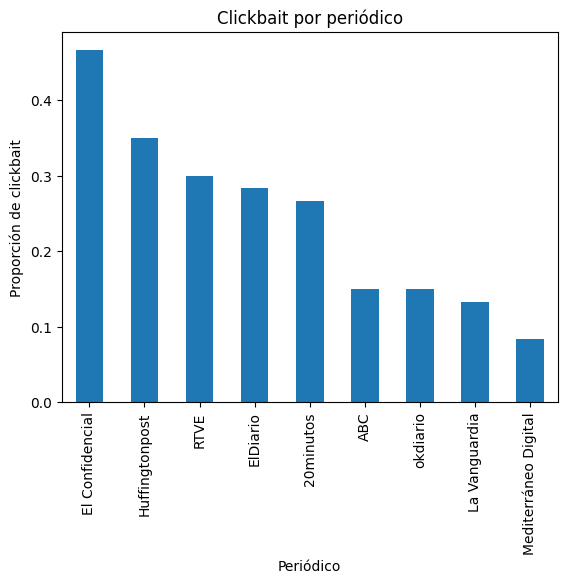

In [9]:
import matplotlib.pyplot as plt

summary["ratio"].plot(kind="bar")
plt.ylabel("Proporción de clickbait")
plt.title("Clickbait por periódico")
plt.show()

In [10]:
df["len_titulo"] = df["Título"].str.len()
df.groupby("cb")["len_titulo"].describe()

,count,mean,std,min,25%,50%,75%,max
cb,,,,,,,,
False,409.0,90.914425,23.424891,23.0,76.0,90.0,106.0,179.0
True,131.0,88.221374,25.461370,27.0,73.0,91.0,108.0,144.0


# Pruebas de métricas

## Longitud del texto


=== LONGITUD EN PALABRAS ===
       count        mean         std   min    25%    50%    75%     max
cb                                                                     
False  409.0  672.511002  802.975878  31.0  313.0  470.0  762.0  9439.0
True   131.0  698.343511  668.728136  11.0  313.5  468.0  812.0  4434.0

=== LONGITUD EN CARACTERES ===
       count         mean          std    min     25%     50%     75%      max
cb                                                                            
False  409.0  4049.286064  4806.249178  172.0  1937.0  2828.0  4760.0  56732.0
True   131.0  4099.908397  3828.132687   68.0  1781.5  2799.0  4933.0  24106.0

=== TEST LONGITUD PALABRAS ===
Statistic: 27051.0
p-value: 0.8666358596125673

=== TEST LONGITUD CARACTERES ===
Statistic: 26712.5
p-value: 0.9607426470137945


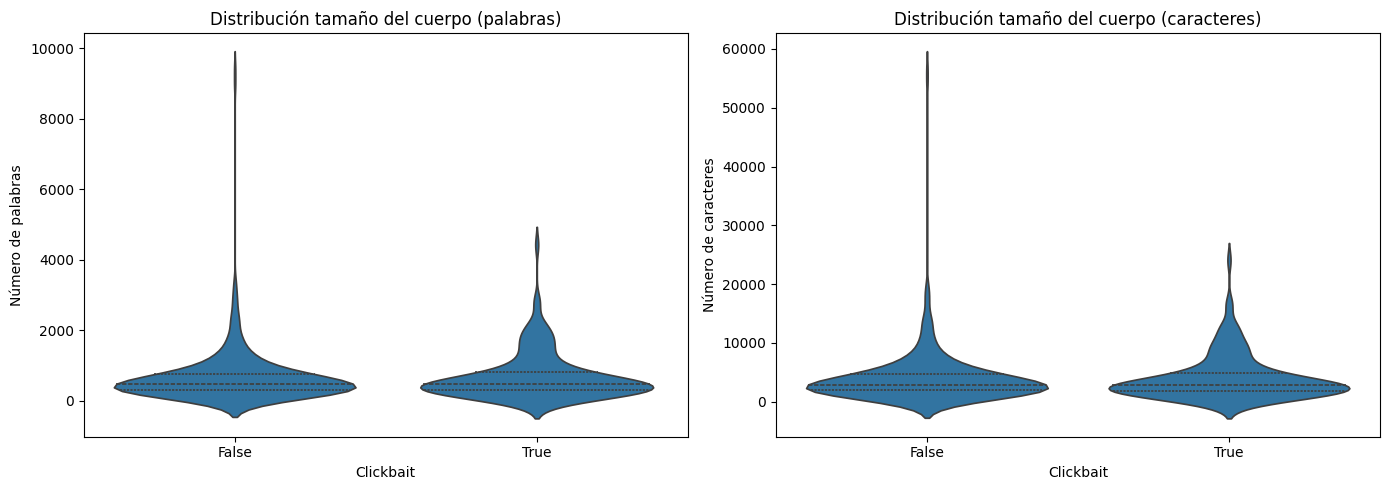

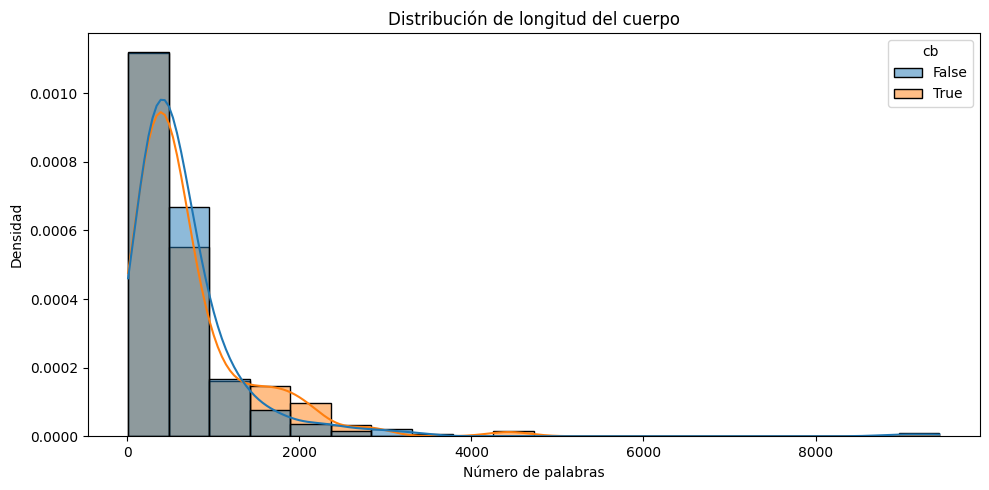

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


# ============================================================
# TAMAÑO DEL CUERPO
# ============================================================

# número de palabras
df["body_length_words"] = df["Contenido"].apply(
    lambda x: len(str(x).split())
)

# número de caracteres
df["body_length_chars"] = df["Contenido"].apply(
    lambda x: len(str(x))
)


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

print("\n=== LONGITUD EN PALABRAS ===")
print(
    df.groupby("cb")["body_length_words"].describe()
)

print("\n=== LONGITUD EN CARACTERES ===")
print(
    df.groupby("cb")["body_length_chars"].describe()
)


# ============================================================
# TEST ESTADÍSTICO
# ============================================================

click_words = df[df["cb"] == True]["body_length_words"]
noclick_words = df[df["cb"] == False]["body_length_words"]

stat_words, p_words = mannwhitneyu(click_words, noclick_words)

print("\n=== TEST LONGITUD PALABRAS ===")
print("Statistic:", stat_words)
print("p-value:", p_words)


click_chars = df[df["cb"] == True]["body_length_chars"]
noclick_chars = df[df["cb"] == False]["body_length_chars"]

stat_chars, p_chars = mannwhitneyu(click_chars, noclick_chars)

print("\n=== TEST LONGITUD CARACTERES ===")
print("Statistic:", stat_chars)
print("p-value:", p_chars)


# ============================================================
# VIOLIN PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(
    data=df,
    x="cb",
    y="body_length_words",
    inner="quartile",
    ax=axes[0]
)

axes[0].set_title("Distribución tamaño del cuerpo (palabras)")
axes[0].set_xlabel("Clickbait")
axes[0].set_ylabel("Número de palabras")


sns.violinplot(
    data=df,
    x="cb",
    y="body_length_chars",
    inner="quartile",
    ax=axes[1]
)

axes[1].set_title("Distribución tamaño del cuerpo (caracteres)")
axes[1].set_xlabel("Clickbait")
axes[1].set_ylabel("Número de caracteres")


plt.tight_layout()
plt.show()


# ============================================================
# HISTOGRAMA SUPERPUESTO
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="body_length_words",
    hue="cb",
    kde=True,
    bins=20,
    stat="density",
    common_norm=False,
    alpha=0.5
)

plt.title("Distribución de longitud del cuerpo")
plt.xlabel("Número de palabras")
plt.ylabel("Densidad")

plt.tight_layout()
plt.show()

## Prueba de legibilidad de Flesch-Kincaid

https://es.wikipedia.org/wiki/Prueba_de_legibilidad_de_Flesch-Kincaid

No hay evidencia estadística de que el clickbait y el no-clickbait difieran en complejidad lingüística medida por legibilidad del contenido. Con el título hay mayor diferencia

la señal de diferencia entre clickbait y no-clickbait aparece débilmente, y depende de la métrica usada.

El clickbait en titulares presenta diferencias estadísticamente significativas en métricas de complejidad lexical sensibles (SMOG, Gunning Fog), pero no en métricas globales de legibilidad (Flesch), lo que sugiere que la variación se concentra en cambios locales de densidad léxica más que en estructura sintáctica global.

In [12]:
import spacy
import syllapy
import numpy as np



def contar_silabas(texto):
    palabras = [w for w in texto.split() if w.isalpha()]
    return sum(syllapy.count(w.lower()) for w in palabras)


def flesch_es(texto):
    doc = nlp(texto)

    oraciones = list(doc.sents)
    palabras = [t.text for t in doc if t.is_alpha]

    n_oraciones = max(len(oraciones), 1)
    n_palabras = max(len(palabras), 1)
    n_silabas = contar_silabas(texto)

    score = 206.84 - 0.60*(n_silabas/n_palabras) - 1.02*(n_palabras/n_oraciones)
    return score

df["flesch"] = df["Contenido"].apply(flesch_es)

resumen = df.groupby("Periódico")["flesch"].agg(["mean", "std", "count"]).sort_values("mean")
print(resumen)

/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/syllapy/data_loader.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


                            mean        std  count
Periódico                                         
Mediterráneo Digital  117.110605  63.710673     60
20minutos             123.375176  97.515957     60
ABC                   148.455437  89.479399     60
Huffingtonpost        151.036651  43.273778     60
El Confidencial       154.546050  32.873475     60
La Vanguardia         170.677775   8.577605     60
RTVE                  173.014697  10.590875     60
ElDiario              176.670168   7.067149     60
okdiario              178.772265   6.402383     60


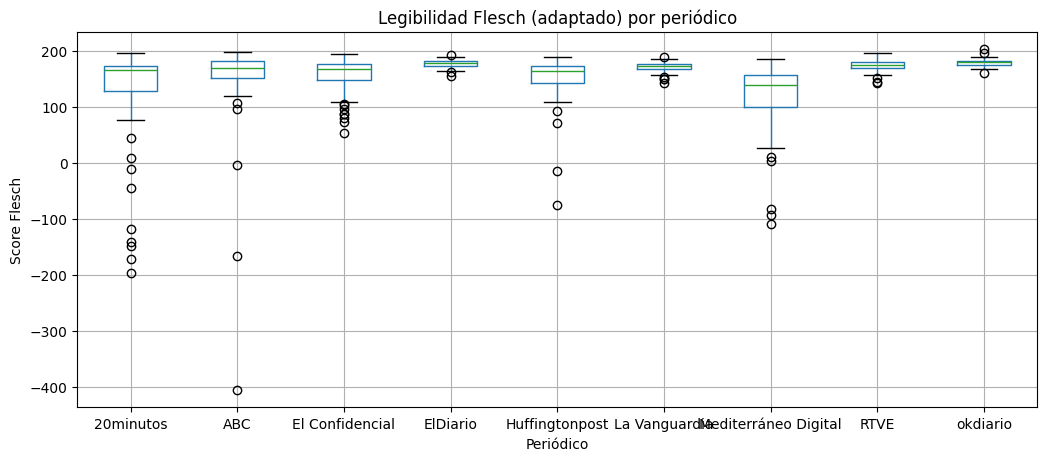

In [13]:
df.boxplot(column="flesch", by="Periódico", figsize=(12,5))
plt.title("Legibilidad Flesch (adaptado) por periódico")
plt.suptitle("")
plt.ylabel("Score Flesch")
plt.show()

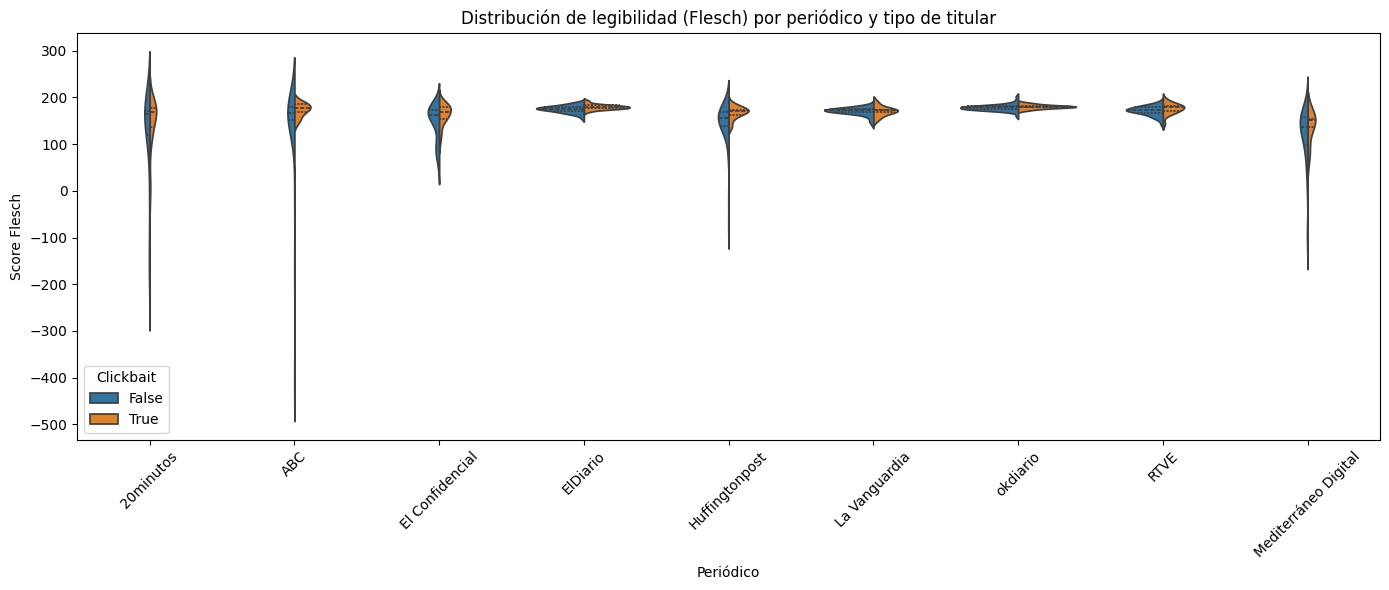

In [14]:

plt.figure(figsize=(14,6))

sns.violinplot(
    data=df,
    x="Periódico",
    y="flesch",
    hue="cb",
    split=True,   # divide clickbait vs no clickbait dentro del mismo violín
    inner="quartile"
)

plt.title("Distribución de legibilidad (Flesch) por periódico y tipo de titular")
plt.xlabel("Periódico")
plt.ylabel("Score Flesch")
plt.xticks(rotation=45)
plt.legend(title="Clickbait")
plt.tight_layout()
plt.show()

In [15]:
clickbait = df[df["cb"] == True]["flesch"].dropna()
noclickbait = df[df["cb"] == False]["flesch"].dropna()

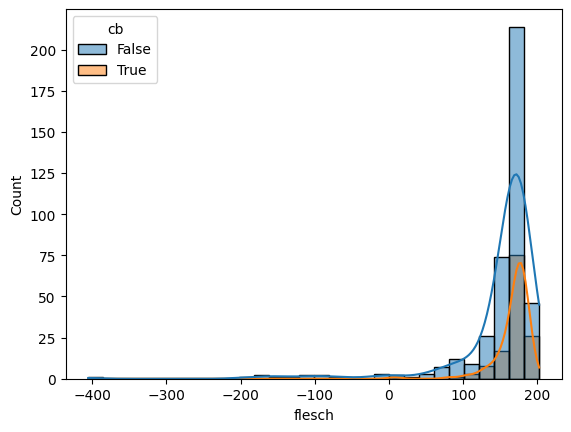

In [16]:
sns.histplot(data=df, x="flesch", hue="cb", kde=True, bins=30)
plt.show()

In [17]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(clickbait, noclickbait)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 32392.0
p-value: 0.00031282677905637073


## Índice de Gunning Fog

In [18]:
import spacy
import syllapy

def gunning_fog(texto):
    doc = nlp(texto)

    palabras = [t.text for t in doc if t.is_alpha]
    oraciones = list(doc.sents)

    n_palabras = len(palabras)
    n_oraciones = max(len(oraciones), 1)

    complejas = sum(1 for w in palabras if syllapy.count(w.lower()) >= 3)

    fog = 0.4 * ((n_palabras / n_oraciones) + 100 * (complejas / n_palabras))
    return fog

df["fog"] = df["Contenido"].apply(gunning_fog)

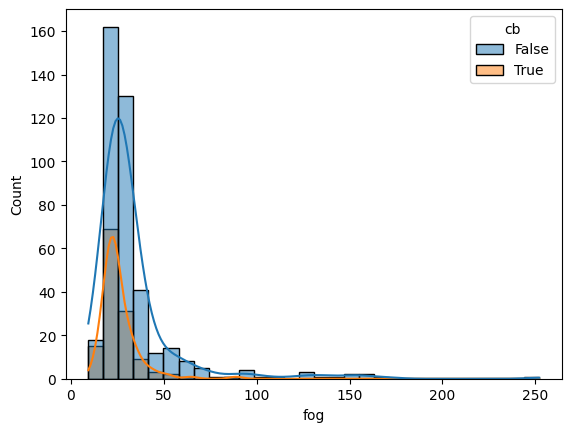

In [19]:
sns.histplot(data=df, x="fog", hue="cb", kde=True, bins=30)
plt.show()

In [20]:
click = df[df["cb"] == True]["fog"]
no_click = df[df["cb"] == False]["fog"]

mannwhitneyu(click, no_click)

MannwhitneyuResult(statistic=np.float64(19338.0), pvalue=np.float64(1.633872174990003e-06))

## Índice de SMOG

In [21]:
import numpy as np

def smog(texto):
    doc = nlp(texto)

    palabras = [t.text for t in doc if t.is_alpha]
    oraciones = list(doc.sents)

    if len(oraciones) == 0:
        return np.nan

    complejas = sum(1 for w in palabras if syllapy.count(w.lower()) >= 3)

    return 1.043 * np.sqrt(complejas * (30 / len(oraciones))) + 3.1291

df["smog"] = df["Título"].apply(smog)

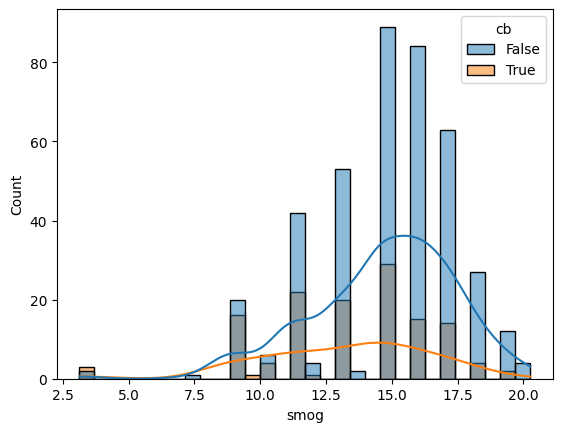

In [22]:
sns.histplot(data=df, x="smog", hue="cb", kde=True, bins=30)
plt.show()

In [23]:
click = df[df["cb"] == True]["smog"]
no_click = df[df["cb"] == False]["smog"]

mannwhitneyu(click, no_click)

MannwhitneyuResult(statistic=np.float64(19515.5), pvalue=np.float64(2.164300922354696e-06))

## Entropía de Shannon


=== ENTROPÍA CONTENIDO ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False  409.0  7.013431  0.684199  4.136243  6.689287  7.063487  7.429897   
True   131.0  7.134730  0.719643  3.321928  6.841114  7.146829  7.588734   

            max  
cb               
False  8.751069  
True   8.566759  

=== ENTROPÍA CONTENIDO NORMALIZADA ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
False  409.0  0.895412  0.030097  0.785504  0.875863  0.895763  0.914424   
True   131.0  0.901406  0.035015  0.810301  0.875453  0.900624  0.926857   

            max  
cb               
False  0.984889  
True   1.000000  

=== ENTROPÍA TÍTULO ===
       count      mean       std       min       25%       50%       75%  \
cb                                                                         
F

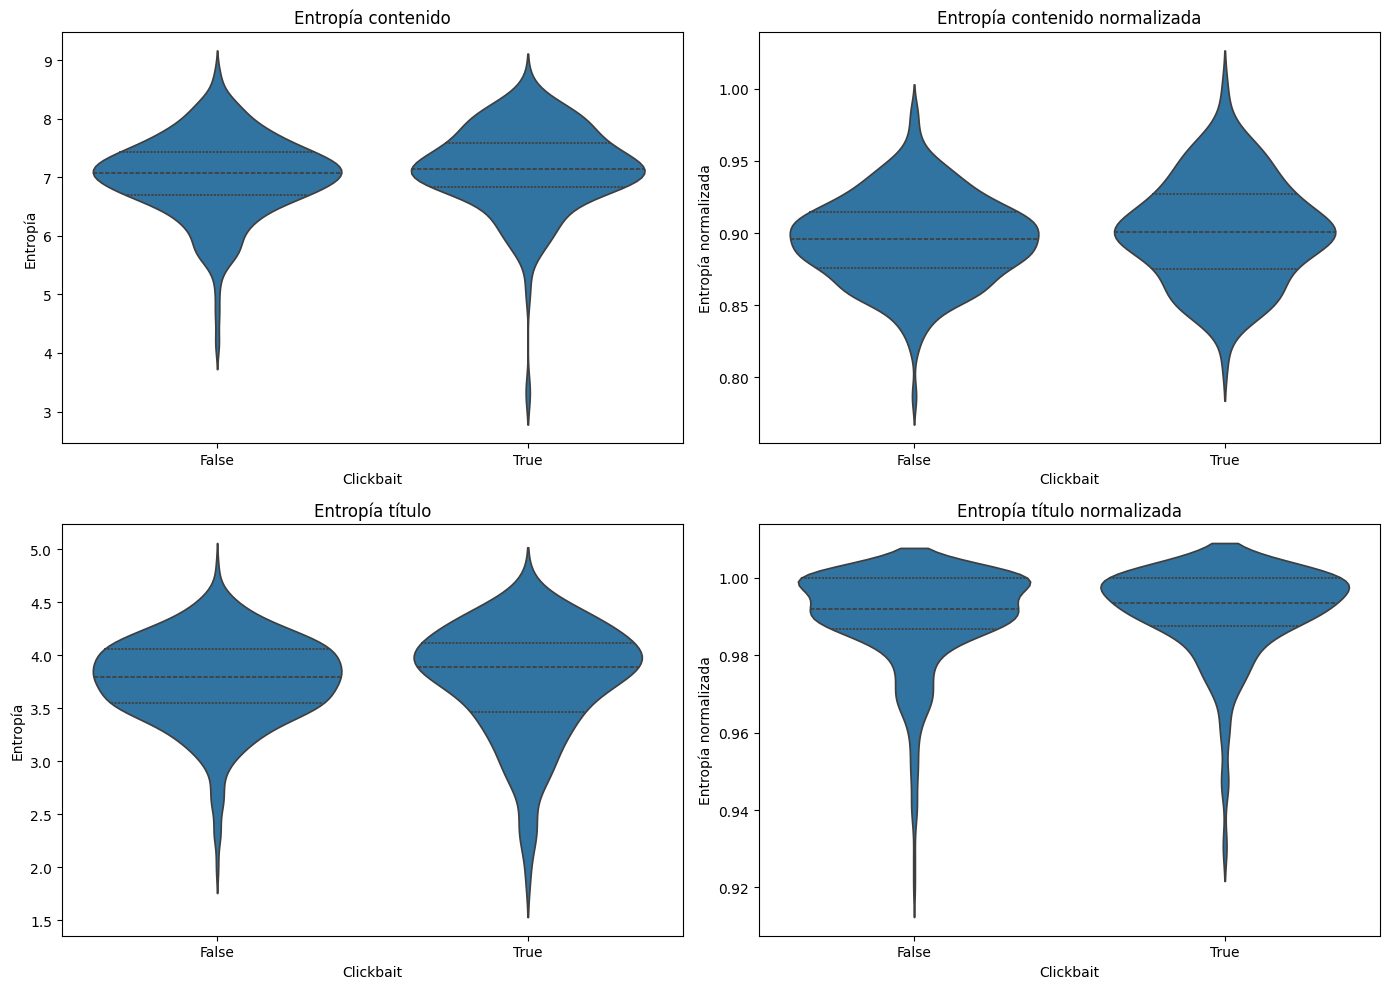

In [24]:
import numpy as np
import pandas as pd
import re

from collections import Counter
from scipy.stats import mannwhitneyu

import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# LIMPIEZA DE TEXTO
# ============================================================

def limpiar_texto(texto):

    if not isinstance(texto, str):
        return ""

    texto = texto.lower()

    # eliminar urls
    texto = re.sub(r"http\S+", "", texto)

    # dejar solo letras y espacios
    texto = re.sub(r"[^a-záéíóúñü\s]", " ", texto)

    # eliminar espacios múltiples
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


# ============================================================
# ENTROPÍA DE SHANNON
# ============================================================

def shannon_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) == 0:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    entropy = -np.sum(probs * np.log2(probs))

    return entropy


# ============================================================
# ENTROPÍA NORMALIZADA
# ============================================================

def normalized_entropy(texto):

    texto = limpiar_texto(texto)

    palabras = texto.split()

    if len(palabras) < 2:
        return np.nan

    freqs = Counter(palabras)

    probs = np.array(list(freqs.values())) / len(palabras)

    H = -np.sum(probs * np.log2(probs))

    Hmax = np.log2(len(freqs))

    if Hmax == 0:
        return 0

    return H / Hmax


# ============================================================
# CALCULAR ENTROPÍAS
# ============================================================

# contenido
df["entropy_content"] = df["Contenido"].apply(shannon_entropy)

# contenido normalizado
df["entropy_content_norm"] = df["Contenido"].apply(normalized_entropy)

# títulos
df["entropy_title"] = df["Título"].apply(shannon_entropy)

# títulos normalizados
df["entropy_title_norm"] = df["Título"].apply(normalized_entropy)


# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================

print("\n=== ENTROPÍA CONTENIDO ===")
print(df.groupby("cb")["entropy_content"].describe())

print("\n=== ENTROPÍA CONTENIDO NORMALIZADA ===")
print(df.groupby("cb")["entropy_content_norm"].describe())

print("\n=== ENTROPÍA TÍTULO ===")
print(df.groupby("cb")["entropy_title"].describe())

print("\n=== ENTROPÍA TÍTULO NORMALIZADA ===")
print(df.groupby("cb")["entropy_title_norm"].describe())


# ============================================================
# TEST MANN-WHITNEY
# ============================================================

def mannwhitney_test(columna):

    click = df[df["cb"] == True][columna].dropna()
    noclick = df[df["cb"] == False][columna].dropna()

    stat, p = mannwhitneyu(click, noclick)

    print(f"\n--- {columna} ---")
    print("Statistic:", stat)
    print("p-value:", p)


mannwhitney_test("entropy_content")
mannwhitney_test("entropy_content_norm")
mannwhitney_test("entropy_title")
mannwhitney_test("entropy_title_norm")


# ============================================================
# VIOLIN PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.violinplot(
    data=df,
    x="cb",
    y="entropy_content",
    inner="quartile",
    ax=axes[0,0]
)

axes[0,0].set_title("Entropía contenido")
axes[0,0].set_xlabel("Clickbait")
axes[0,0].set_ylabel("Entropía")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_content_norm",
    inner="quartile",
    ax=axes[0,1]
)

axes[0,1].set_title("Entropía contenido normalizada")
axes[0,1].set_xlabel("Clickbait")
axes[0,1].set_ylabel("Entropía normalizada")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_title",
    inner="quartile",
    ax=axes[1,0]
)

axes[1,0].set_title("Entropía título")
axes[1,0].set_xlabel("Clickbait")
axes[1,0].set_ylabel("Entropía")


sns.violinplot(
    data=df,
    x="cb",
    y="entropy_title_norm",
    inner="quartile",
    ax=axes[1,1]
)

axes[1,1].set_title("Entropía título normalizada")
axes[1,1].set_xlabel("Clickbait")
axes[1,1].set_ylabel("Entropía normalizada")


plt.tight_layout()
plt.show()

## LSA

In [25]:
# corpus=cargar_datos(1)
similitudes,tfidf_lsa=LSA_vectors(corpus,min_df=2)


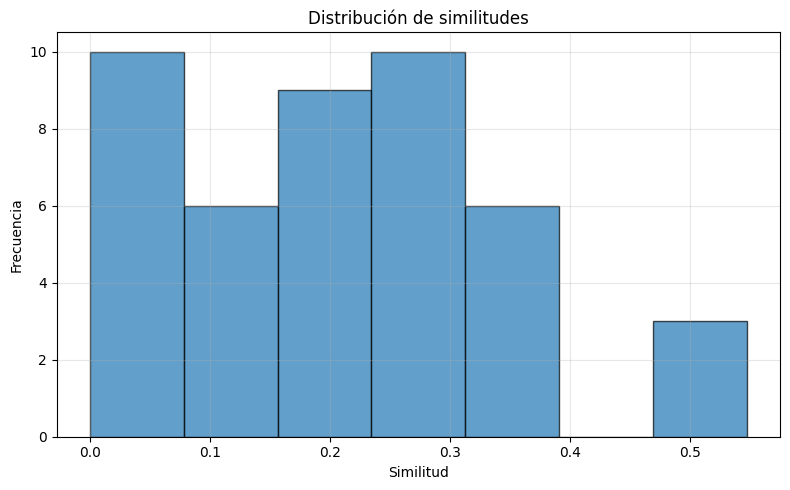

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    similitudes,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embeding semántico

Aplicar:Crear un vector adicional de features de decticos, puntuación, superlativos. Si el embeding cae en una zona del espacio muy cargada de adjetivos pero el cuerpo está en una zona neutral, esa diferencia puede ser indicios de clickbait.

Título: una corte de apelaciones en nueva york falla en contra de la política de detención de migrantes de trump


Fragmentos:
  Fragmento 1: un nuevo revés para el presidente donald trump en nueva
  Fragmento 2: york. un tribunal de apelaciones de este estado ha fallado
  Fragmento 3: este martes en contra de la política del republicano que
  Fragmento 4: instruye a las autoridades a detener sin posibilidad de fianza
  Fragmento 5: a los migrantes que captura en el país.de manera unánime
  Fragmento 6: los tres jueces del tribunal del segundo circuito en nueva
  Fragmento 7: york han rechazado la interpretación que el gobierno le está
  Fragmento 8: dando a la ley de migración al forzar a las
  Fragmento 9: personas que son arrestadas por las autoridades migratorias a permanecer
  Fragmento 10: detenidas mientras se resuelven sus casos procesos que pueden durar
  Fragmento 11: meses o incluso años.en el fallo los jueces han dicho
  Fragmento 12: que aceptar esa política supondría el m

Batches: 100%|██████████| 2/2 [00:00<00:00,  3.20it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


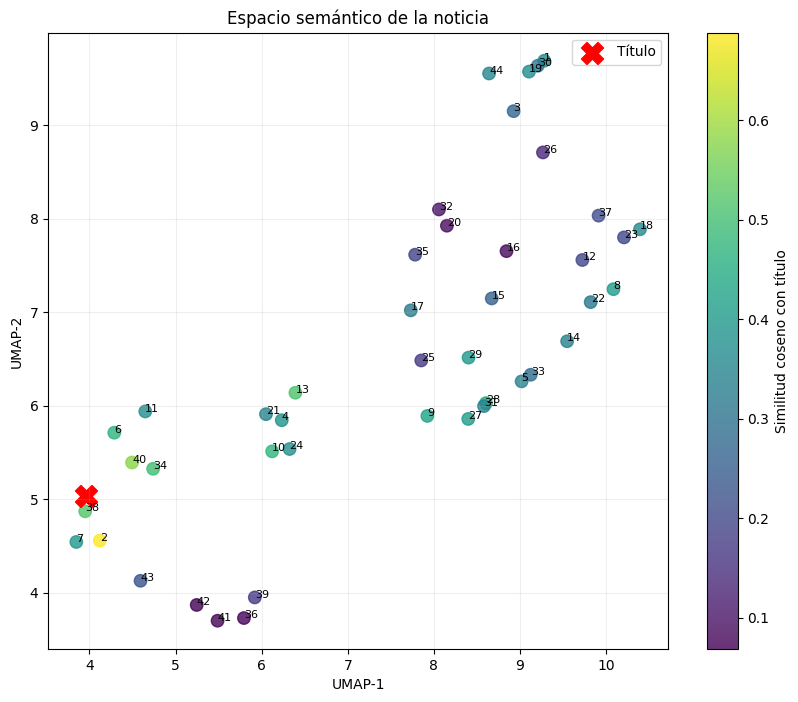

In [27]:
# corpus=cargar_datos(1)
titulo, fragmentos_contenido,noticia=cargar_datos(noticias, n_noticia=5, print_info=True)
corpus = [titulo] + fragmentos_contenido

similarities,embeddings=embedding_sentence_transformers(corpus,embedding_model)
embedding_2d=embedding_umap(similarities,embeddings, plot=True)

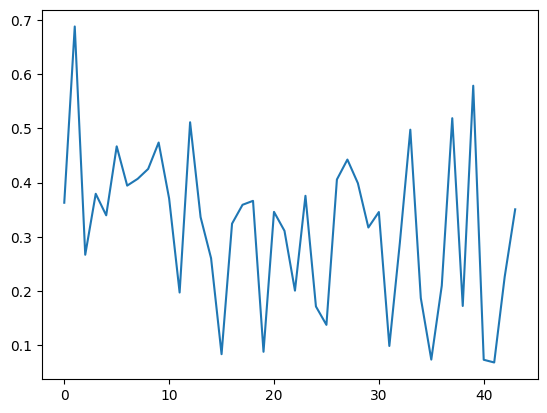

In [28]:
plt.plot(similarities)

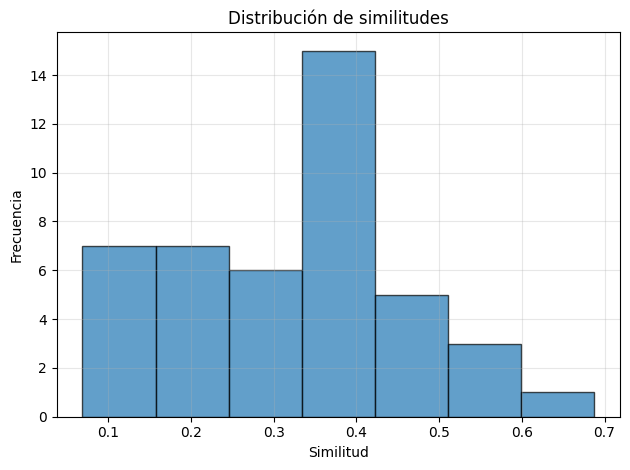

In [29]:
plt.hist(
    similarities,
    bins=7,          # Número de bins
    edgecolor='black',
    alpha=0.7
)

plt.xlabel("Similitud")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitudes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Embeding semántico + Features lingüísticos

Se ha decidido añadir un feature lingüístico con el objetivo de comparar el lenguaje emotivo/directo entre el título y el cuerpo de la noticia. Estos features capturan ese patrón: títulos con muchos deícticos y puntuación atraen pero el contenido es neutral.
Contadores de deícticos (yo, tú, él...), puntuación (!, ?, ¡¿) y superlativos (muy, increíblemente, -ísimo).

- Para que se puedan comparar el deícticos, puntuación y los superlativos se ha decidido normalizar con StandardScaler

- Se calcula el score como:
$$score=(1-similitud)\cdot diferencia_lingüística$$
De tal forma que si la similitud es 1 en el espacio embebido será 0.
Cuánto más sea la diferencia entre el título y el contenido mayor será el diferencia_lingüística.

De tal forma que solo será alto si ambas condiciones ocurren.

Batches: 100%|██████████| 2/2 [00:00<00:00, 10.53it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


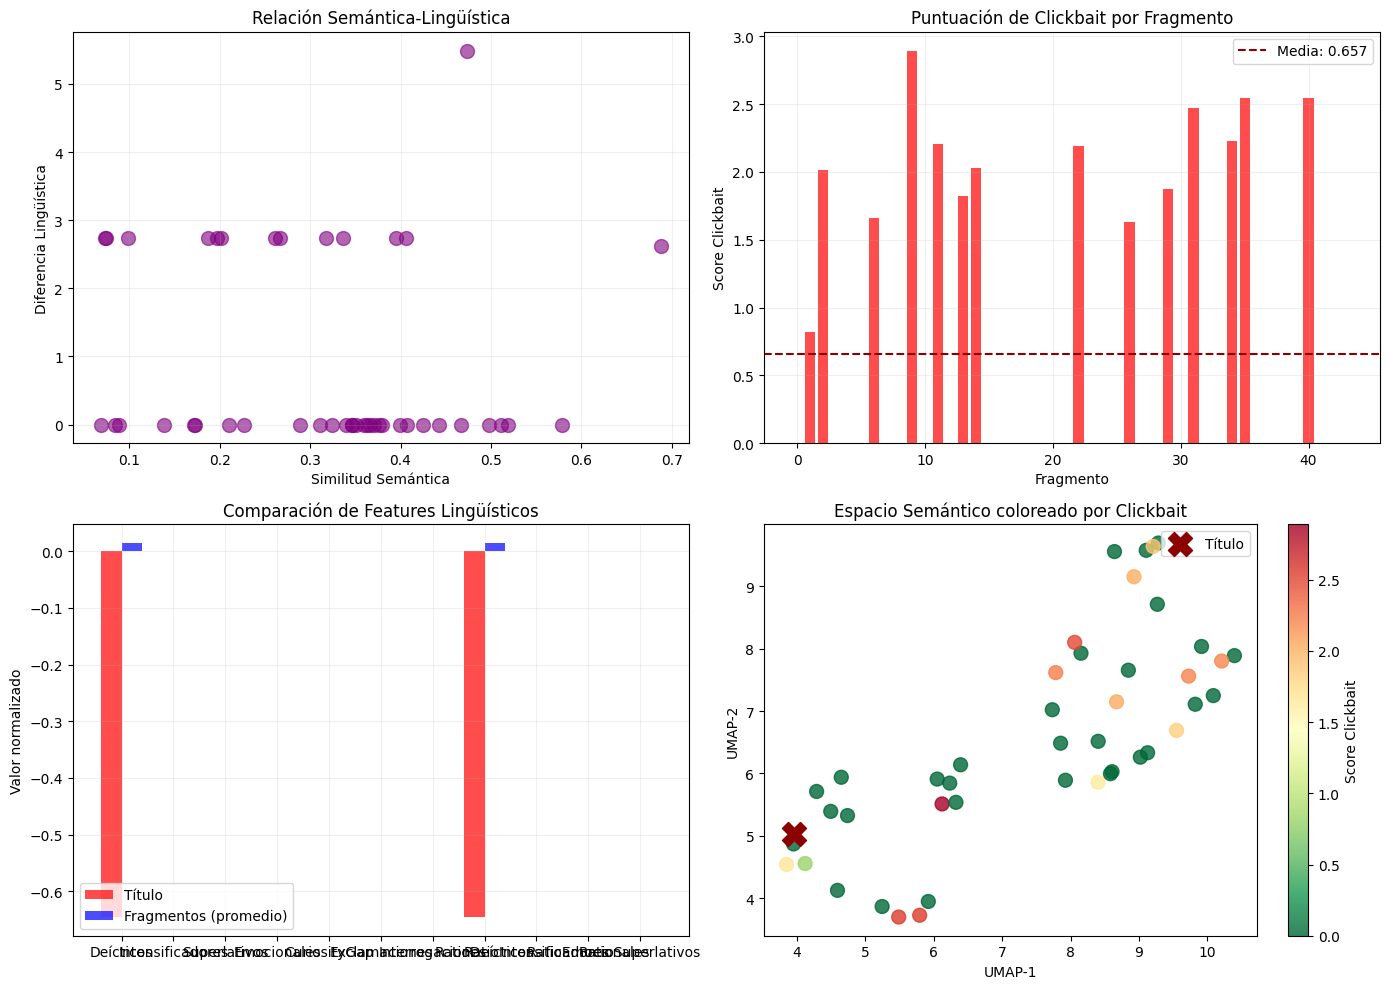

In [30]:

def analizar_clickbait(noticias, n_noticia, embedding_model, plot=False):
    """
    Combina embeddings semánticos con features lingüísticos para detectar clickbait
    input: noticias (list), n_noticia (int), plot (bool)
    output: score_medio (float), análisis (dict)
    """
    # 1. Cargar datos
    
    titulo, fragmentos, noticia = cargar_datos(noticias, n_noticia)
    periodico=noticia["Periódico"]
    categoria=noticia["Categoría"]
    contenido=noticia["Contenido"]
    link=noticia["Link"]
    corpus = [titulo] + fragmentos
    
    # 2. Extraer features lingüísticos
    features_ling = extraer_features_linguisticos(corpus)
    diferencias_ling, (titulo_norm, fragmentos_norm) = calcular_diferencia_features(corpus)
    
    # 3. Embeddings semánticos
    similarities, embeddings = embedding_sentence_transformers(corpus,embedding_model)
    embedding_2d = embedding_umap(similarities, embeddings, plot=False)


    # 3.1 Information structure features ---------------------------------- NUEVO
    similarities_array = np.array(similarities)

    # posición del máximo (relevancia tardía)
    argmax_relevance = np.argmax(similarities_array)

    # normalizado (0 = inicio, 1 = final)
    position_relevance = argmax_relevance / (len(similarities_array) - 1 + 1e-8)

    # information delay (qué tan tarde aparece la info relevante)
    information_delay = position_relevance 
    split = len(similarities_array) // 2

    early_mean = np.mean(similarities_array[:split])
    late_mean = np.mean(similarities_array[split:])

    early_late_ratio = early_mean / (late_mean + 1e-8)
    #------------------------------------------------------------------------------ NUEVO
    # 4. Normalizar features lingüísticos
    scaler = StandardScaler()
    features_norm = scaler.fit_transform(features_ling)
    titulo_features = features_norm[0]
    fragmentos_features = features_norm[1:]
    
    # 5. Distancia en espacio UMAP
    titulo_2d = embedding_2d[0]
    fragmentos_2d = embedding_2d[1:]
    dist_semantica = np.linalg.norm(fragmentos_2d - titulo_2d, axis=1)
    
    # 6. SCORE CLICKBAIT: (1 - similitud semántica) × distancia lingüística

    score_clickbait = (1 - similarities) * diferencias_ling


    score_medio = np.mean(score_clickbait)
    
    # NUEVAS MÉTRICAS
    shock_value = calcular_shock_value(corpus)
    promise_gap = calcular_promise_gap(corpus)
    anticipation_idx = calcular_anticipation_index(corpus)
    



    analisis = {
        'titulo': titulo,
        'contenido': contenido,
        'periodico': periodico,
        'categoria': categoria,
        'link': link,
        'score_clickbait': score_clickbait,
        'score_medio': score_medio,
        'similitud_semantica': similarities,
        'diferencias_linguisticas': diferencias_ling,
        'dist_semantica': dist_semantica,
        'features_titulo': titulo_features,
        'features_fragmentos': fragmentos_features,
        'information_delay': information_delay,
        'position_relevance': position_relevance,
        'early_late_ratio': early_late_ratio,
        'argmax_relevance': argmax_relevance,
        'shock_value': shock_value,
        'promise_gap': promise_gap,
        'anticipation_index': anticipation_idx,

    }
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Similitud semántica vs distancia lingüística
        axes[0, 0].scatter(similarities, diferencias_ling, s=100, alpha=0.6, color='purple')
        axes[0, 0].set_xlabel('Similitud Semántica')
        axes[0, 0].set_ylabel('Diferencia Lingüística')
        axes[0, 0].set_title('Relación Semántica-Lingüística')
        axes[0, 0].grid(alpha=0.2)
        
        # Score de clickbait por fragmento
        axes[0, 1].bar(range(len(score_clickbait)), score_clickbait, color='red', alpha=0.7)
        axes[0, 1].axhline(y=score_medio, color='darkred', linestyle='--', label=f'Media: {score_medio:.3f}')
        axes[0, 1].set_xlabel('Fragmento')
        axes[0, 1].set_ylabel('Score Clickbait')
        axes[0, 1].set_title('Puntuación de Clickbait por Fragmento')
        axes[0, 1].legend()
        axes[0, 1].grid(alpha=0.2)
        
        # Features: título vs fragmentos
        features_names = [
            'Deícticos',
            'Intensificadores',
            'Superlativos',
            'Emocionales',
            'CuriosityGap',
            'Exclamaciones',
            'Interrogaciones',
            #'PuntosSuspensivos',
            #'Mayúsculas',
            #'Números',
            'RatioDeícticos',
            'RatioIntensificadores',
            'RatioEmocionales',
            'RatioSuperlativos'
        ]
        x_pos = np.arange(len(features_names))
        titulo_vals = titulo_features
        fragmentos_vals = np.mean(fragmentos_features, axis=0)
        
        axes[1, 0].bar(x_pos - 0.2, titulo_vals, 0.4, label='Título', color='red', alpha=0.7)
        axes[1, 0].bar(x_pos + 0.2, fragmentos_vals, 0.4, label='Fragmentos (promedio)', color='blue', alpha=0.7)
        axes[1, 0].set_ylabel('Valor normalizado')
        axes[1, 0].set_title('Comparación de Features Lingüísticos')
        axes[1, 0].set_xticks(x_pos)
        axes[1, 0].set_xticklabels(features_names)
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.2)
        
        # Espacio UMAP coloreado por score clickbait
        x = embedding_2d[:, 0]
        y = embedding_2d[:, 1]
        scatter = axes[1, 1].scatter(x[1:], y[1:], c=score_clickbait, cmap='RdYlGn_r', s=100, alpha=0.8)
        axes[1, 1].scatter(x[0], y[0], color='darkred', s=300, marker='X', label='Título')
        axes[1, 1].set_xlabel('UMAP-1')
        axes[1, 1].set_ylabel('UMAP-2')
        axes[1, 1].set_title('Espacio Semántico coloreado por Clickbait')
        axes[1, 1].legend()
        plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
        
        plt.tight_layout()
        plt.show()
    
    return score_medio, analisis

score, datos = analizar_clickbait(noticias, 5, embedding_model, plot=True)

In [31]:
# ESTE CÓDIGO NO ESTÁ BIEN MIRADO, SOLO ERAP ARA SACAR RESULTADOS RÁPIDOS DE LO ANTERIOR

def procesar_todas_noticias(noticias):
    """
    Procesa todas las noticias y calcula score de clickbait
    input: noticias (list)
    output: dataframe con scores y metadatos
    """
    resultados = []
    
    for n in range(len(noticias)):
        try:
            score_medio, analisis = analizar_clickbait(noticias, n, embedding_model, plot=False)
            
            noticia = noticias[n]
            resultados.append({
                'id_noticia': n,
                'titulo': noticia.get('Título', ''),
                'contenido': noticia.get('Contenido', ''),
                'categoria': noticia.get('Categoría', ''),
                'periodico': noticia.get('Periódico', ''),
                'clickbait': noticia.get('cb', False),
                'score_clickbait': score_medio,
                'similitud_media': np.median(analisis['similitud_semantica']),
                'diferencia_ling_media': np.mean(analisis['diferencias_linguisticas']),
                'deicticos_titulo': analisis['features_titulo'][0],
                'puntuacion_titulo': analisis['features_titulo'][1],
                'superlativos_titulo': analisis['features_titulo'][2],
                'information_delay': analisis['information_delay'],
                'position_relevance': analisis['position_relevance'],
                'early_late_ratio': analisis['early_late_ratio'],
                'argmax_relevance': analisis['argmax_relevance'],
                'shock_value': analisis['shock_value'],
                'promise_gap': analisis['promise_gap'],
                'anticipation_index': analisis['anticipation_index'],

            })
            
            print(f"✓ Noticia {n}/{len(noticias)-1}")
        
        except Exception as e:
            print(f"✗ Error en noticia {n}: {e}")
    
    df = pd.DataFrame(resultados)
    return df


def visualizar_resultados_clickbait(df):
    """
    Visualiza histogramas y estadísticas de clickbait
    input: df (pandas DataFrame)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Histograma de scores
    axes[0, 0].hist(df['score_clickbait'], bins=30, color='red', alpha=0.7, edgecolor='black')
    axes[0, 0].axvline(df['score_clickbait'].mean(), color='darkred', linestyle='--', 
                       label=f'Media: {df["score_clickbait"].mean():.3f}')
    axes[0, 0].axvline(df['score_clickbait'].median(), color='orange', linestyle='--', 
                       label=f'Mediana: {df["score_clickbait"].median():.3f}')
    axes[0, 0].set_xlabel('Score Clickbait')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].set_title('Distribución de Scores de Clickbait')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.2)
    
    # 2. Score por categoría
    df.boxplot(column='score_clickbait', by='categoria', ax=axes[0, 1])
    axes[0, 1].set_title('Score de Clickbait por Categoría')
    axes[0, 1].set_xlabel('Categoría')
    axes[0, 1].set_ylabel('Score Clickbait')
    plt.sca(axes[0, 1])
    plt.xticks(rotation=45, ha='right')
    
    # 3. Score por periódico
    df.boxplot(column='score_clickbait', by='periodico', ax=axes[1, 0])
    axes[1, 0].set_title('Score de Clickbait por Periódico')
    axes[1, 0].set_xlabel('Periódico')
    axes[1, 0].set_ylabel('Score Clickbait')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=45, ha='right')
    
    # 4. Scatter: similitud vs diferencia lingüística
    scatter = axes[1, 1].scatter(df['similitud_media'], df['diferencia_ling_media'], 
                                c=df['score_clickbait'], cmap='RdYlGn_r', s=100, alpha=0.6)
    axes[1, 1].set_xlabel('Similitud Semántica Media')
    axes[1, 1].set_ylabel('Diferencia Lingüística Media')
    axes[1, 1].set_title('Relación Semántica-Lingüística')
    plt.colorbar(scatter, ax=axes[1, 1], label='Score Clickbait')
    axes[1, 1].grid(alpha=0.2)
    
    plt.tight_layout()
    plt.show()


def estadisticas_clickbait(df):
    """
    Imprime estadísticas generales
    input: df (pandas DataFrame)
    """
    print("\n" + "="*80)
    print("ESTADÍSTICAS DE CLICKBAIT")
    print("="*80)
    
    print(f"\n📊 GENERAL:")
    print(f"  • Total noticias: {len(df)}")
    print(f"  • Score medio: {df['score_clickbait'].mean():.3f}")
    print(f"  • Score máximo: {df['score_clickbait'].max():.3f}")
    print(f"  • Score mínimo: {df['score_clickbait'].min():.3f}")
    print(f"  • Desviación estándar: {df['score_clickbait'].std():.3f}")
    
    print(f"\n🏆 NOTICIAS CON MAYOR CLICKBAIT:")
    top_5 = df.nlargest(5, 'score_clickbait')[['id_noticia', 'titulo', 'categoria', 'score_clickbait']]
    for idx, row in top_5.iterrows():
        print(f"  {row['id_noticia']}. [{row['categoria']}] {row['titulo'][:60]}... ({row['score_clickbait']:.3f})")
    
    print(f"\n📁 POR CATEGORÍA:")
    for cat in df['categoria'].unique():
        df_cat = df[df['categoria'] == cat]
        print(f"  • {cat}: {len(df_cat)} noticias, media={df_cat['score_clickbait'].mean():.3f}")
    
    print(f"\n📰 POR PERIÓDICO:")
    for per in df['periodico'].unique():
        df_per = df[df['periodico'] == per]
        print(f"  • {per}: {len(df_per)} noticias, media={df_per['score_clickbait'].mean():.3f}")


# USO
df_resultados = procesar_todas_noticias(noticias)
estadisticas_clickbait(df_resultados)
# Guardar resultados
df_resultados.to_csv('resultados_clickbait.csv', index=False)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches: 100%|██████████| 3/3 [00:00<00:00, 19.53it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 0/539


Batches: 100%|██████████| 2/2 [00:00<00:00, 23.68it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 1/539


...

✓ Noticia 537/539


Batches: 100%|██████████| 2/2 [00:00<00:00, 27.20it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 538/539


Batches: 100%|██████████| 1/1 [00:00<00:00, 15.30it/s]
/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ Noticia 539/539

ESTADÍSTICAS DE CLICKBAIT

📊 GENERAL:
  • Total noticias: 540
  • Score medio: 1.185
  • Score máximo: 7.447
  • Score mínimo: 0.000
  • Desviación estándar: 0.913

🏆 NOTICIAS CON MAYOR CLICKBAIT:
  386. [Nacional] despliegue policial en un centro de la línea tras la brutal ... (7.447)
  275. [Nacional] carlos cuerpo aspiro a cubrir ese espacio de mayor sosiego y... (6.844)
  147. [Nacional] ¿por qué majadahonda está tan cerca y getafe tan lejos?... (6.466)
  360. [Internacional] el vicepresidente vance el primero en ser rescatado del tiro... (6.288)
  295. [Cultura] ayuso vuelve a españa y un catedrático de historia le dedica... (5.755)

📁 POR CATEGORÍA:
  • Internacional: 190 noticias, media=1.152
  • Nacional: 190 noticias, media=1.162
  • Cultura: 160 noticias, media=1.252

📰 POR PERIÓDICO:
  • 20minutos: 60 noticias, media=1.288
  • ABC: 60 noticias, media=1.145
  • El Confidencial: 60 noticias, media=1.305
  • ElDiario: 60 noticias, media=1.233
  • Huffingtonpo

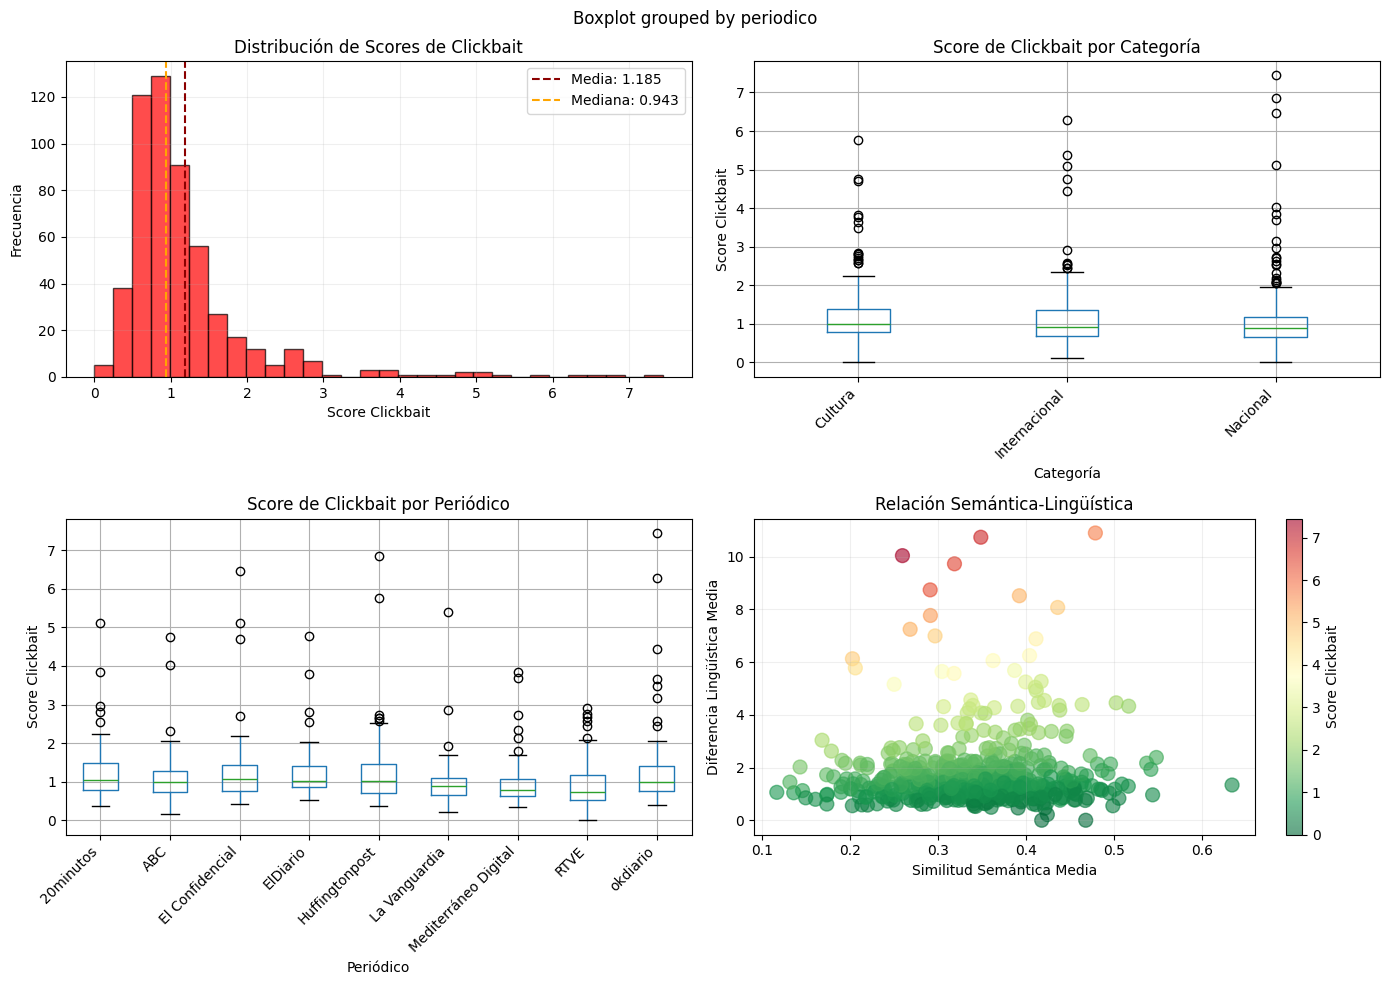

In [32]:
visualizar_resultados_clickbait(df_resultados)

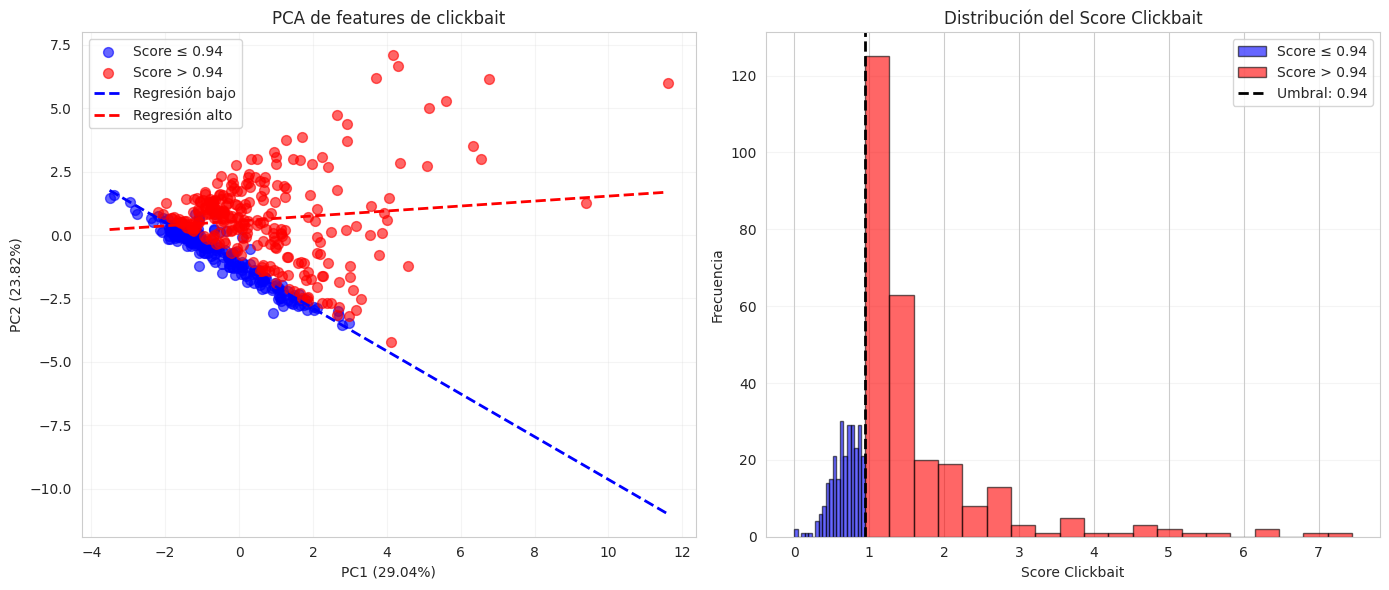

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

df = pd.read_csv("resultados_clickbait.csv")

features = [
    "score_clickbait",
    "similitud_media",
    "diferencia_ling_media",
    "deicticos_titulo",
    "puntuacion_titulo",
    "superlativos_titulo",
    "information_delay",
    "position_relevance",
    "early_late_ratio",
    "argmax_relevance",
]

X = df[features].fillna(0).values
y = df["clickbait"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Umbral
threshold = df["score_clickbait"].median()
bajo = df["score_clickbait"] <= threshold
alto = df["score_clickbait"] > threshold

# Regresiones lineales
reg_bajo = LinearRegression()
reg_bajo.fit(X_pca[bajo, 0].reshape(-1, 1), X_pca[bajo, 1])

reg_alto = LinearRegression()
reg_alto.fit(X_pca[alto, 0].reshape(-1, 1), X_pca[alto, 1])

x_line = np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 100)

fig = plt.figure(figsize=(14, 6))

# PCA
ax1 = plt.subplot(1, 2, 1)
ax1.scatter(X_pca[bajo, 0], X_pca[bajo, 1], label=f"Score ≤ {threshold:.2f}", alpha=0.6, s=50, color="blue")
ax1.scatter(X_pca[alto, 0], X_pca[alto, 1], label=f"Score > {threshold:.2f}", alpha=0.6, s=50, color="red")
ax1.plot(x_line, reg_bajo.predict(x_line.reshape(-1, 1)), "b--", linewidth=2, label="Regresión bajo")
ax1.plot(x_line, reg_alto.predict(x_line.reshape(-1, 1)), "r--", linewidth=2, label="Regresión alto")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax1.set_title("PCA de features de clickbait")
ax1.legend()
ax1.grid(alpha=0.2)

# Histograma
ax2 = plt.subplot(1, 2, 2)
ax2.hist(df[bajo]["score_clickbait"], bins=20, alpha=0.6, label=f"Score ≤ {threshold:.2f}", color="blue", edgecolor="black")
ax2.hist(df[alto]["score_clickbait"], bins=20, alpha=0.6, label=f"Score > {threshold:.2f}", color="red", edgecolor="black")
ax2.axvline(threshold, color="black", linestyle="--", linewidth=2, label=f"Umbral: {threshold:.2f}")
ax2.set_xlabel("Score Clickbait")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución del Score Clickbait")
ax2.legend()
ax2.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

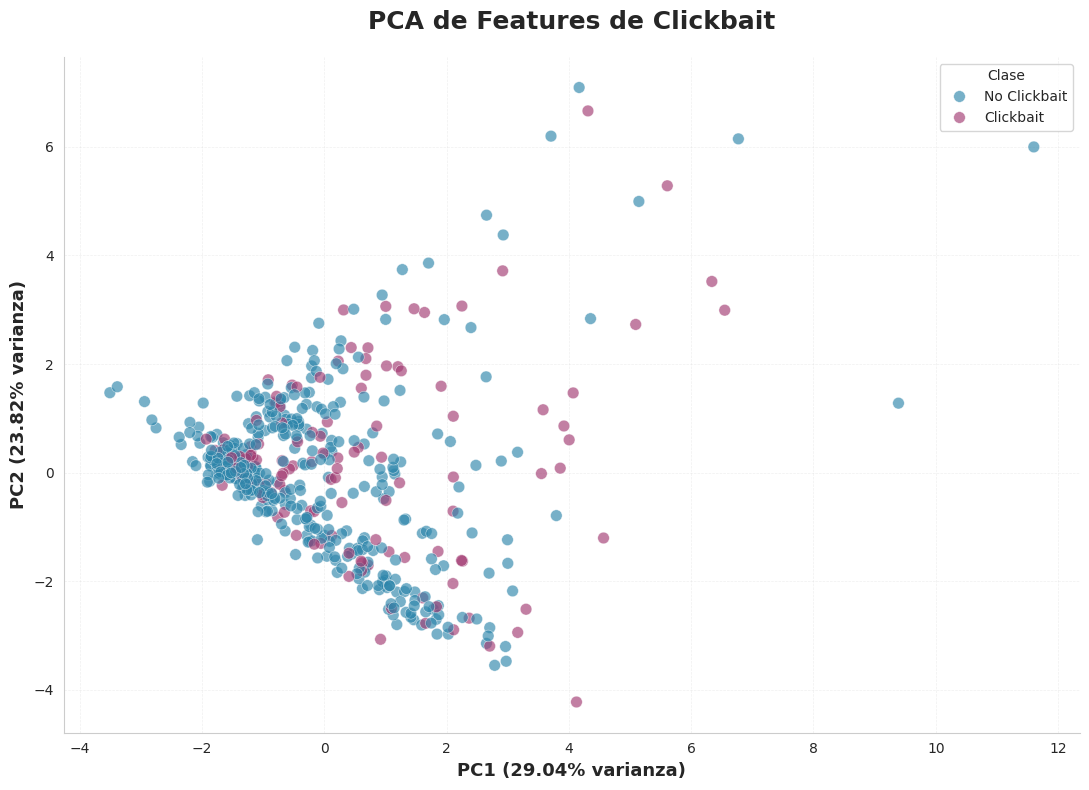

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# =========================
# Cargar datos
# =========================

df = pd.read_csv("resultados_clickbait.csv")

features = [
    "score_clickbait",
    "similitud_media",
    "diferencia_ling_media",
    "deicticos_titulo",
    "puntuacion_titulo",
    "superlativos_titulo",
    "information_delay",
    "position_relevance",
    "early_late_ratio",
    "argmax_relevance",
]

X = df[features].fillna(0).values

# =========================
# Escalado
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# PCA
# =========================

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# DataFrame para plotting
# =========================

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Clase": [
        "Clickbait" if x else "No Clickbait"
        for x in df["clickbait"]
    ]
})

# =========================
# Estilo visual
# =========================

sns.set_style("whitegrid")

palette = {
    "No Clickbait": "#2E86AB",
    "Clickbait": "#A23B72"
}

# =========================
# Figura
# =========================

fig, ax = plt.subplots(figsize=(11, 8))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Clase",
    palette=palette,
    alpha=0.65,
    s=70,
    edgecolor="white",
    linewidth=0.4,
    ax=ax
)

# =========================
# Título y labels
# =========================

ax.set_title(
    "PCA de Features de Clickbait",
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax.set_xlabel(
    f"PC1",
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    f"PC2 ",
    fontsize=13,
    fontweight='bold'
)

# =========================
# Grid refinado
# =========================

ax.grid(
    True,
    alpha=0.3,
    linestyle='--',
    linewidth=0.5
)

# =========================
# Leyenda
# =========================

ax.legend(
    title="Clase",
    frameon=True,
    fancybox=True
)

# =========================
# Estilo final
# =========================

sns.despine()

plt.tight_layout()
plt.show()

In [35]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

df = pd.read_csv("resultados_clickbait.csv")

features = [
    "score_clickbait",
    "diferencia_ling_media",
    "information_delay",
    "argmax_relevance",
]

X = df[features].fillna(0).values
y = df["clickbait"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Umbral
threshold = df["score_clickbait"].median()
bajo = df["score_clickbait"] <= threshold
alto = df["score_clickbait"] > threshold

# Regresiones lineales
reg_bajo = LinearRegression()
reg_bajo.fit(X_pca[bajo, 0].reshape(-1, 1), X_pca[bajo, 1])

reg_alto = LinearRegression()
reg_alto.fit(X_pca[alto, 0].reshape(-1, 1), X_pca[alto, 1])

x_line = np.linspace(X_pca[:, 0].min(), X_pca[:, 0].max(), 100)

# DataFrame para Plotly
df_plot = pd.DataFrame({
    'Dim 1': X_pca[:, 0],
    'Dim 2': X_pca[:, 1],
    'Score': df['score_clickbait'],
    'Es Clickbait': df['clickbait'].astype(str),
    'Titulo': df['titulo']
})

# Crear figura base con scatter
fig = px.scatter(
    df_plot, 
    x='Dim 1', 
    y='Dim 2', 
    color='Score',
    symbol='Es Clickbait',
    hover_name='Titulo',
    hover_data={'Score': ':.2f', 'Es Clickbait': True, 'Dim 1': False, 'Dim 2': False},
    color_continuous_scale='plasma',
    title="Análisis Interactivo de Clickbait con Regresiones",
    labels={'Es Clickbait': '¿Es Clickbait?'}
)

# Agregar línea de regresión para Score BAJO
fig.add_trace(go.Scatter(
    x=x_line,
    y=reg_bajo.predict(x_line.reshape(-1, 1)),
    mode='lines',
    name=f'Regresión Score ≤ {threshold:.2f}',
    line=dict(color='blue', width=3, dash='dash')
))

# Agregar línea de regresión para Score ALTO
fig.add_trace(go.Scatter(
    x=x_line,
    y=reg_alto.predict(x_line.reshape(-1, 1)),
    mode='lines',
    name=f'Regresión Score > {threshold:.2f}',
    line=dict(color='red', width=3, dash='dash')
))

# Ajustes de estilo
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color='White')))
fig.update_layout(
    template='plotly_white',
    width=1000,
    height=700,
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.2%})",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.2%})"
)

fig.show()

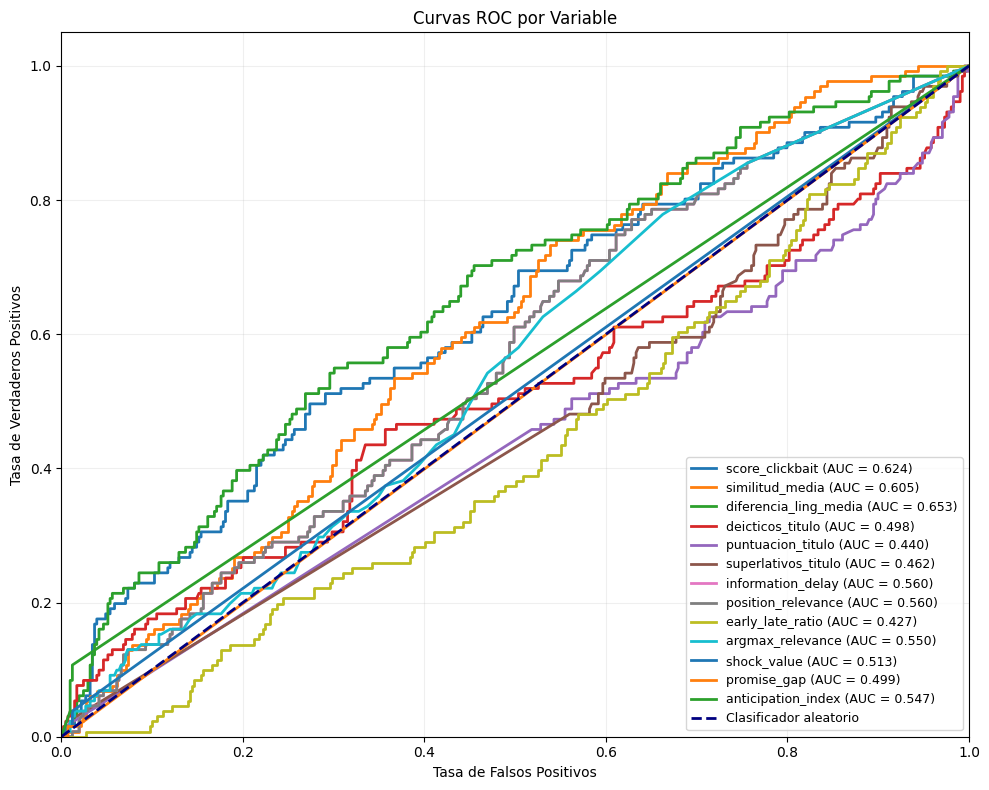


Ranking AUC por variable:
diferencia_ling_media: 0.653
score_clickbait: 0.624
similitud_media: 0.605
information_delay: 0.560
position_relevance: 0.560
argmax_relevance: 0.550
anticipation_index: 0.547
shock_value: 0.513
promise_gap: 0.499
deicticos_titulo: 0.498
superlativos_titulo: 0.462
puntuacion_titulo: 0.440
early_late_ratio: 0.427


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# MAL!! HACERLO SOBRE LA PCA
df = pd.read_csv("resultados_clickbait.csv")

features = [
    "score_clickbait",
    "similitud_media",
    "diferencia_ling_media",
    "deicticos_titulo",
    "puntuacion_titulo",
    "superlativos_titulo",
    "information_delay",
    "position_relevance",
    "early_late_ratio",
    "argmax_relevance",
    'shock_value',
    'promise_gap',
    'anticipation_index'
]

y = df["clickbait"].values

fig, ax = plt.subplots(figsize=(10, 8))

auc_scores = {}

for feature in features:
    X = df[feature].fillna(0).values
    
    fpr, tpr, _ = roc_curve(y, X)
    roc_auc = auc(fpr, tpr)
    auc_scores[feature] = roc_auc
    
    ax.plot(fpr, tpr, lw=2, label=f'{feature} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC por Variable')
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Ranking de variables
print("\nRanking AUC por variable:")
for feature, score in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {score:.3f}")

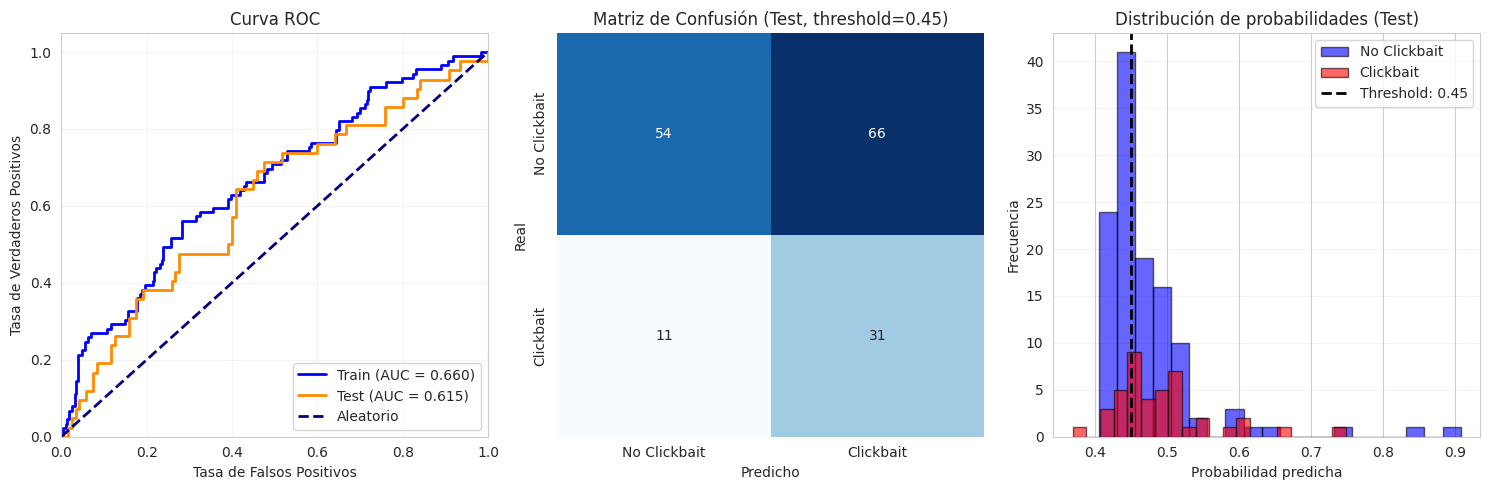

=== TRAIN ===
              precision    recall  f1-score   support

No Clickbait       0.85      0.42      0.56       289
   Clickbait       0.29      0.75      0.41        89

    accuracy                           0.50       378
   macro avg       0.57      0.59      0.49       378
weighted avg       0.71      0.50      0.53       378

AUC: 0.660

=== TEST ===
              precision    recall  f1-score   support

No Clickbait       0.83      0.45      0.58       120
   Clickbait       0.32      0.74      0.45        42

    accuracy                           0.52       162
   macro avg       0.58      0.59      0.51       162
weighted avg       0.70      0.52      0.55       162

AUC: 0.615


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import seaborn as sns


df = pd.read_csv("resultados_clickbait.csv")

features = [
    "score_clickbait",
    #"similitud_media",
    "diferencia_ling_media",
    # "deicticos_titulo",
    # "puntuacion_titulo",
    # "superlativos_titulo",
    # "information_delay",
    # "position_relevance",
    # "early_late_ratio",
    #"argmax_relevance",
]

X = df[features].fillna(0).values
y = df["clickbait"].values

# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar clasificador
clf = LogisticRegression(random_state=42, class_weight='balanced')


clf.fit(X_train_scaled, y_train)

# Probabilidades
y_proba_train = clf.predict_proba(X_train_scaled)[:, 1]
y_proba_test = clf.predict_proba(X_test_scaled)[:, 1]

# Curvas ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_proba_train)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)
roc_auc_test = auc(fpr_test, tpr_test)

fig = plt.figure(figsize=(15, 5))

# Curva ROC
ax1 = plt.subplot(1, 3, 1)
ax1.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Train (AUC = {roc_auc_train:.3f})')
ax1.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test (AUC = {roc_auc_test:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('Tasa de Falsos Positivos')
ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.set_title('Curva ROC')
ax1.legend(loc="lower right")
ax1.grid(alpha=0.2)

# Matriz de confusión
threshold = 0.45
ax2 = plt.subplot(1, 3, 2)
y_pred_test = (y_proba_test >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Predicho')
ax2.set_ylabel('Real')
ax2.set_title(f'Matriz de Confusión (Test, threshold={threshold})')
ax2.set_xticklabels(['No Clickbait', 'Clickbait'])
ax2.set_yticklabels(['No Clickbait', 'Clickbait'])

# Distribución de probabilidades
ax3 = plt.subplot(1, 3, 3)
ax3.hist(y_proba_test[y_test == 0], bins=20, alpha=0.6, label='No Clickbait', color='blue', edgecolor='black')
ax3.hist(y_proba_test[y_test == 1], bins=20, alpha=0.6, label='Clickbait', color='red', edgecolor='black')
ax3.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {threshold}')
ax3.set_xlabel('Probabilidad predicha')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de probabilidades (Test)')
ax3.legend()
ax3.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

print("=== TRAIN ===")
print(classification_report(y_train, (y_proba_train >= threshold).astype(int), target_names=['No Clickbait', 'Clickbait']))
print(f"AUC: {roc_auc_train:.3f}\n")

print("=== TEST ===")
print(classification_report(y_test, y_pred_test, target_names=['No Clickbait', 'Clickbait']))
print(f"AUC: {roc_auc_test:.3f}")

### Question Answering (QA)

Convertir el titular en una pregunta con un transformers de QA y ver si encuentra la respuesta en qué frase del texto, si es al final del texto o no aparece puede dar indicios de clickbait



### Buscar si el cuerpo aporta más información (entropía)

Ver la redundaicia por párrafos, separar en porcentaje de texto que tenga, es decir, ver 0-25% la entropía, luego de 25-50% etc

Hipótesis: El contenido en noticias con clickbait tienen una tasa de redundancia muy alta. Dice mucho en el título y casi nada de información nueva en el contenido (entropía baja)